# Liquidation Market Data EDA

**Goal.** Build intuition about Binance trades, Binance BBO,
Binance liquidations, and Bybit liquidations through pure
exploration before building any predictive signal.

This notebook is an executable report over the full-data EDA
artifacts generated by the project pipeline.  Core metrics and
conclusions are computed on the full train/validation data; only
distribution plots use deterministic visual samples to keep figures
readable.

**Author:** Sergei Smirnov  
**Project:** CMF HFT / market microstructure research

## 0. Reproducibility and Scope

The raw parquet files are intentionally not committed.  The full EDA
pipeline can be reproduced locally with:

```bash
PYTHONPATH=src .venv/bin/python -m cmf_backtester.main run-liquidation-eda \
  --config configs/liquidation_eda.yaml --profile full
```

The latest full run processed more than one billion Binance trades,
so this notebook does not rerun that expensive computation by
default.  Instead it loads the generated full-data CSV tables and
figures from `reports/liquidation_eda/`.

In [1]:
from pathlib import Path
import json
import math

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6g}")

cwd = Path.cwd()
ROOT = cwd if (cwd / "reports" / "liquidation_eda").exists() else cwd.parent
REPORT_DIR = ROOT / "reports" / "liquidation_eda"
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"
META_PATH = REPORT_DIR / "run_metadata.json"

assert REPORT_DIR.exists(), f"Missing report directory: {REPORT_DIR}"
assert META_PATH.exists(), f"Missing metadata: {META_PATH}"

with META_PATH.open("r", encoding="utf-8") as f:
    metadata = json.load(f)

def read_table(name: str) -> pd.DataFrame:
    path = TABLE_DIR / name
    assert path.exists(), f"Missing table: {path}"
    return pd.read_csv(path)

def show_table(name: str, n: int = 12, sort_by=None, ascending=True, title: str | None = None) -> pd.DataFrame:
    df = read_table(name)
    view = df
    if sort_by is not None and sort_by in view.columns:
        view = view.sort_values(sort_by, ascending=ascending)
    if title:
        display(Markdown(f"**{title}**"))
    display(view.head(n))
    display(Markdown(f"`{name}`: {len(df):,} rows, {len(df.columns):,} columns."))
    return df

def show_figure(name: str, width: int = 980) -> None:
    path = FIG_DIR / name
    assert path.exists(), f"Missing figure: {path}"
    display(Image(filename=str(path), width=width))

display(Markdown(f"Loaded full EDA artifacts from `{REPORT_DIR}`."))

Loaded full EDA artifacts from `/Users/nuwanda/Desktop/Nuwanda/CMF/reports/liquidation_eda`.

The metadata below is the first sanity check: the notebook is reading
a full-profile run, not a toy sample.  The row counts are also used
later to verify that the full-data markout loop covered all Binance
trades and all Binance BBO updates.

In [2]:
meta_view = pd.DataFrame(
    [
        ("profile", metadata.get("profile")),
        ("generated_at_utc", metadata.get("generated_at_utc")),
        ("full_data_mode", metadata.get("full_data_mode")),
        ("processed_trade_rows_full", metadata.get("processed_trade_rows_full")),
        ("processed_bbo_rows_full", metadata.get("processed_bbo_rows_full")),
        ("processed_trade_batches_full", metadata.get("processed_trade_batches_full")),
        ("full_data_dates_processed", metadata.get("full_data_dates_processed")),
        ("full_data_batch_minutes", metadata.get("full_data_batch_minutes")),
        ("full_data_eda_seconds", metadata.get("phase_seconds", {}).get("full_data_eda")),
    ],
    columns=["field", "value"],
)
display(meta_view)

,field,value
0,profile,full
1,generated_at_utc,2026-05-21T21:45:58Z
2,full_data_mode,True
3,processed_trade_rows_full,1107782898
4,processed_bbo_rows_full,206966513
5,processed_trade_batches_full,4320
6,full_data_dates_processed,90
7,full_data_batch_minutes,60
8,full_data_eda_seconds,"5,898.23"


**Interpretation.** The EDA was run in full mode.  The key design
choice was to process data symbol-by-symbol and day/hour batch by
batch, writing compact aggregates instead of keeping enriched trades
in memory.  This is the right style for HFT data: the full dataset is
too large for notebook-first row-wise exploration.

## 1. Dataset Shape and Coverage

First we inspect the four data families:

- Binance trades;
- Binance BBO / book ticker snapshots;
- Binance liquidations;
- Bybit liquidations.

The purpose of this block is basic orientation: source sizes,
date coverage, duplicate timestamps, and train/validation split
balance.

In [3]:
source_files = show_table("source_files.csv", n=8, title="Source files")
time_coverage = show_table("time_coverage.csv", n=8, title="Time coverage and duplicate timestamps")
train_validation_drift = show_table("train_validation_drift.csv", n=16, title="Train/validation row counts by source")

**Source files**

,source,venue,data_type,symbol,ticker,path,size_mb,exists
0,binance_trades,binance,trades,btcusdt,perp:btcusdt,data/raw/liquidation_task/data/binance_trades/...,"1,294.43",True
1,binance_booktickers,binance,bbo,btcusdt,perp:btcusdt,data/raw/liquidation_task/data/binance_booktic...,796.615,True
2,binance_liquidations,binance,liquidations,btcusdt,perp:btcusdt,data/raw/liquidation_task/data/binance_liquida...,1.44586,True
3,bybit_liquidations,bybit,liquidations,btcusdt,btcusdt,data/raw/liquidation_task/data/bybit_liquidati...,2.43722,True
4,binance_trades,binance,trades,ethusdt,perp:ethusdt,data/raw/liquidation_task/data/binance_trades/...,"2,118.51",True
5,binance_booktickers,binance,bbo,ethusdt,perp:ethusdt,data/raw/liquidation_task/data/binance_booktic...,"1,249.32",True
6,binance_liquidations,binance,liquidations,ethusdt,perp:ethusdt,data/raw/liquidation_task/data/binance_liquida...,1.81294,True
7,bybit_liquidations,bybit,liquidations,ethusdt,ethusdt,data/raw/liquidation_task/data/bybit_liquidati...,1.79894,True


`source_files.csv`: 8 rows, 8 columns.

**Time coverage and duplicate timestamps**

,rows,min_timestamp,max_timestamp,unique_timestamps,duplicate_timestamp_rows,timestamp_nulls,ticker_nulls,side_nulls,price_nulls,amount_nulls,min_price,max_price,min_amount,max_amount,source,venue,data_type,symbol,min_datetime_utc,max_datetime_utc,bid_price_nulls,bid_amount_nulls,ask_price_nulls,ask_amount_nulls,min_bid_price,max_ask_price,min_bid_amount,min_ask_amount,max_bid_amount,max_ask_amount
0,401902513,1764547200047000,1772323199992000,85036917,316865596,0,0,0,0,0,"59,800","97,932.1",0.001,724.359,binance_trades,binance,trades,btcusdt,2025-12-01T00:00:00.047000+00:00,2026-02-28T23:59:59.992000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,99169477,1764547202075000,1772323199949000,99169477,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,binance_booktickers,binance,bbo,btcusdt,2025-12-01T00:00:02.075000+00:00,2026-02-28T23:59:59.949000+00:00,0,0,0,0,"59,821.4","97,909.9",0.001,0.001,"1,081.75","1,093.63"
2,114255,1764547206091000,1772323150548000,114255,0,0,0,0,0,0,"59,122.3","177,135",0.001,223,binance_liquidations,binance,liquidations,btcusdt,2025-12-01T00:00:06.091000+00:00,2026-02-28T23:59:10.548000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,228655,1764547202915000,1772323122271000,223561,5094,0,0,0,0,0,"59,636.3","98,384.6",0.001,50.105,bybit_liquidations,bybit,liquidations,btcusdt,2025-12-01T00:00:02.915000+00:00,2026-02-28T23:58:42.271000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,705880385,1764547200016000,1772323199993000,108296437,597583948,0,0,0,0,0,"1,736.02","3,446.12",0.001,"8,685.14",binance_trades,binance,trades,ethusdt,2025-12-01T00:00:00.016000+00:00,2026-02-28T23:59:59.993000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,107797036,1764547200683000,1772323199829000,107797036,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,binance_booktickers,binance,bbo,ethusdt,2025-12-01T00:00:00.683000+00:00,2026-02-28T23:59:59.829000+00:00,0,0,0,0,"1,739.33","3,446.12",0.001,0.001,"60,427.9","59,753.2"
6,131769,1764547209455000,1772322590541000,131769,0,0,0,0,0,0,0.01,"4,095.62",0.001,"6,968.7",binance_liquidations,binance,liquidations,ethusdt,2025-12-01T00:00:09.455000+00:00,2026-02-28T23:49:50.541000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,160214,1764547207779000,1772321662075000,157550,2664,0,0,0,0,0,"1,735.03","3,462.91",0.01,"2,177.36",bybit_liquidations,bybit,liquidations,ethusdt,2025-12-01T00:00:07.779000+00:00,2026-02-28T23:34:22.075000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`time_coverage.csv`: 8 rows, 30 columns.

**Train/validation row counts by source**

,source,symbol,split,rows
0,binance_booktickers,btcusdt,train,65654006
1,binance_trades,ethusdt,train,388981166
2,bybit_liquidations,btcusdt,train,124465
3,binance_trades,btcusdt,validation,190513050
4,binance_booktickers,ethusdt,validation,35257016
5,binance_booktickers,ethusdt,train,72540020
6,binance_booktickers,btcusdt,validation,33515471
7,binance_trades,btcusdt,train,211389463
8,binance_liquidations,btcusdt,train,63660
9,bybit_liquidations,ethusdt,train,97116


`train_validation_drift.csv`: 16 rows, 4 columns.

In [4]:
expected_trades = (
    metadata["source_rows"]["binance_trades:btcusdt"]
    + metadata["source_rows"]["binance_trades:ethusdt"]
)
expected_bbo = (
    metadata["source_rows"]["binance_booktickers:btcusdt"]
    + metadata["source_rows"]["binance_booktickers:ethusdt"]
)
coverage_check = pd.DataFrame(
    [
        ("Binance trades", expected_trades, metadata["processed_trade_rows_full"]),
        ("Binance BBO", expected_bbo, metadata["processed_bbo_rows_full"]),
    ],
    columns=["family", "raw_rows_expected", "rows_processed_by_full_eda"],
)
coverage_check["match"] = coverage_check["raw_rows_expected"] == coverage_check["rows_processed_by_full_eda"]
display(coverage_check)

,family,raw_rows_expected,rows_processed_by_full_eda,match
0,Binance trades,1107782898,1107782898,True
1,Binance BBO,206966513,206966513,True


**Findings.**

- The full EDA covers all Binance trades and all Binance BBO rows
  used for markouts and order-book diagnostics.
- Trades have many duplicate timestamps.  This is expected in
  high-frequency market data: multiple executions can share the same
  microsecond timestamp.  The files do not provide a separate event
  sequence id, so same-timestamp ordering is ambiguous and must not
  be invented.
- BBO rows have no duplicate timestamps in this dataset, which makes
  backward-as-of joins stable for book state lookup.
- Bybit liquidation timestamps can duplicate; we treat them as event
  batches at the same visible time and apply the required 200 ms
  availability delay before using them as features.

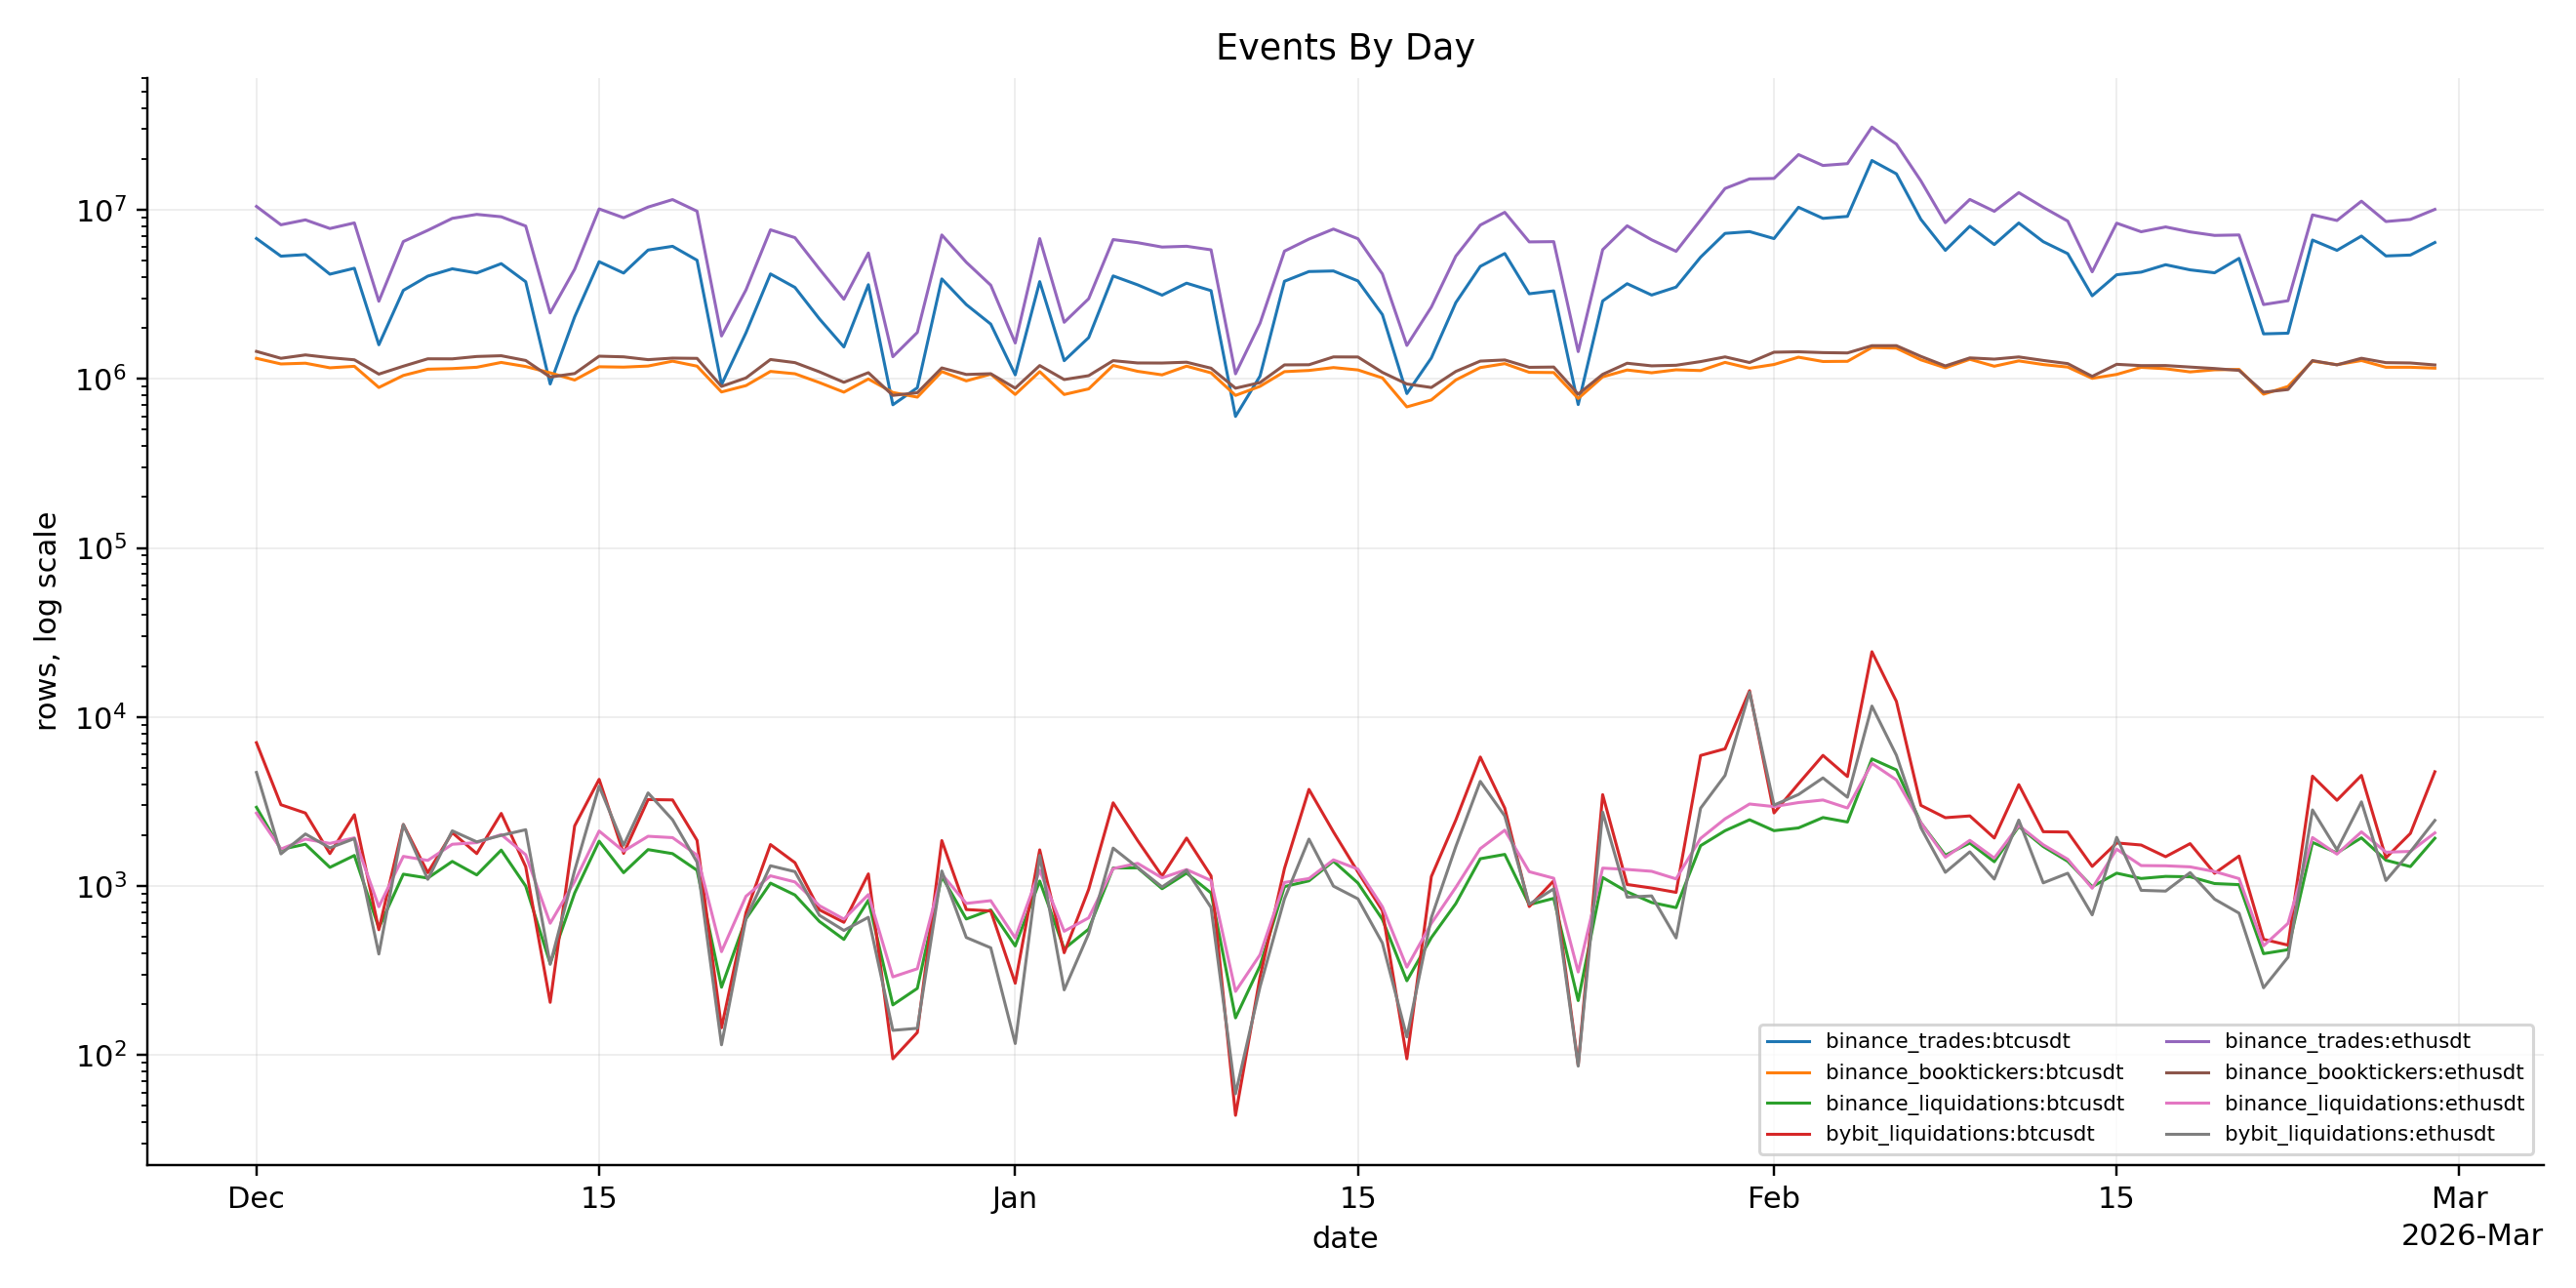

In [5]:
show_figure("event_counts_by_day.png")

**Figure interpretation.** Event counts are plotted on a log scale
because trades and BBO updates are orders of magnitude more frequent
than liquidations.  This confirms the main practical constraint of
the project: trades/BBO require batch aggregation, while
liquidation data is sparse enough for richer event studies.

In [6]:
daily_counts = read_table("daily_event_counts.csv")
daily_intensity = (
    daily_counts
    .groupby(["source", "symbol"], as_index=False)
    .agg(
        total_rows=("rows", "sum"),
        median_rows_per_day=("rows", "median"),
        p90_rows_per_day=("rows", lambda s: s.quantile(0.90)),
        max_rows_per_day=("rows", "max"),
        min_rows_per_day=("rows", "min"),
    )
)
daily_intensity["burst_ratio_max_to_median"] = (
    daily_intensity["max_rows_per_day"] / daily_intensity["median_rows_per_day"]
)
display(daily_intensity.sort_values(["source", "symbol"]))

top_liquidation_days = (
    daily_counts[daily_counts["source"].str.contains("liquidations")]
    .sort_values("rows", ascending=False)
    .head(12)
)
display(Markdown("**Largest liquidation-count days**"))
display(top_liquidation_days)

,source,symbol,total_rows,median_rows_per_day,p90_rows_per_day,max_rows_per_day,min_rows_per_day,burst_ratio_max_to_median
0,binance_booktickers,btcusdt,99169477,1.1317e+06,1.273e+06,1533586,682900,1.35511
1,binance_booktickers,ethusdt,107797036,1.22547e+06,1.36321e+06,1572412,798605,1.28311
2,binance_liquidations,btcusdt,114255,"1,137","2,133.1",5650,166,4.96922
3,binance_liquidations,ethusdt,131769,"1,307.5","2,380.9",5313,238,4.06348
4,binance_trades,btcusdt,401902513,4.14749e+06,7.27415e+06,19580992,599776,4.72117
5,binance_trades,ethusdt,705880385,7.41191e+06,1.27136e+07,30864956,1071409,4.16424
6,bybit_liquidations,btcusdt,228655,"1,770","4,534",24310,44,13.7345
7,bybit_liquidations,ethusdt,160214,"1,221.5","3,485.6",14032,59,11.4875


**Largest liquidation-count days**

,source,venue,data_type,symbol,date,rows
336,bybit_liquidations,bybit,liquidations,btcusdt,2026-02-05,24310
331,bybit_liquidations,bybit,liquidations,btcusdt,2026-01-31,14299
691,bybit_liquidations,bybit,liquidations,ethusdt,2026-01-31,14032
337,bybit_liquidations,bybit,liquidations,btcusdt,2026-02-06,12364
696,bybit_liquidations,bybit,liquidations,ethusdt,2026-02-05,11600
270,bybit_liquidations,bybit,liquidations,btcusdt,2025-12-01,7042
330,bybit_liquidations,bybit,liquidations,btcusdt,2026-01-30,6483
697,bybit_liquidations,bybit,liquidations,ethusdt,2026-02-06,5935
334,bybit_liquidations,bybit,liquidations,btcusdt,2026-02-03,5925
329,bybit_liquidations,bybit,liquidations,btcusdt,2026-01-29,5917


**Quant research read.** The dataset is not a stationary stream of
independent events.  Activity clusters by day and source.  For a
trading signal this matters because a feature that works on quiet
days may fail during liquidation cascades, and a model trained on raw
event counts can overfit to volatility/activity regimes.  The right
next step is therefore regime-aware validation: compare signal
behavior on high-liquidation days, normal days, and weekend/low
liquidity periods instead of trusting a single aggregate score.

## 2. Schema, Data Quality, and Conventions

This block checks the conventions that can silently break a trading
research task:

- timestamps are UNIX microseconds in UTC;
- Binance trade `side` is taker side;
- liquidation `side` is liquidation order side;
- Bybit liquidations become available only after 200 ms;
- known-at-time joins must be backward/as-of joins.

In [7]:
schema_audit = show_table("schema_audit.csv", n=8, title="Schema audit")
bbo_quality = show_table("bbo_quality.csv", n=12, title="BBO quality by day")
anomaly_log = show_table("anomaly_log.csv", n=25, title="Anomaly log")

**Schema audit**

,source,venue,data_type,symbol,ok,issue,columns,dtypes,expected_columns
0,binance_trades,binance,trades,btcusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"
1,binance_booktickers,binance,bbo,btcusdt,True,NaN,"timestamp,ticker,bid_price,bid_amount,ask_pric...","Int64,String,Float64,Float64,Float64,Float64","timestamp,ticker,bid_price,bid_amount,ask_pric..."
2,binance_liquidations,binance,liquidations,btcusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"
3,bybit_liquidations,bybit,liquidations,btcusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"
4,binance_trades,binance,trades,ethusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"
5,binance_booktickers,binance,bbo,ethusdt,True,NaN,"timestamp,ticker,bid_price,bid_amount,ask_pric...","Int64,String,Float64,Float64,Float64,Float64","timestamp,ticker,bid_price,bid_amount,ask_pric..."
6,binance_liquidations,binance,liquidations,ethusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"
7,bybit_liquidations,bybit,liquidations,ethusdt,True,NaN,"timestamp,ticker,side,price,amount","Int64,String,String,Float64,Float64","timestamp,ticker,side,price,amount"


`schema_audit.csv`: 8 rows, 9 columns.

**BBO quality by day**

,split,date,symbol,rows,crossed_rows,locked_rows,nonpositive_bid_rows,nonpositive_ask_rows,negative_bid_amount_rows,negative_ask_amount_rows,mean_spread_bps,mean_queue_imbalance
0,train,2025-12-01,btcusdt,1322826,0,0,0,0,0,0,0.0140991,0.499764
1,train,2025-12-02,btcusdt,1225630,0,0,0,0,0,0,0.0128294,0.498836
2,train,2025-12-03,btcusdt,1238214,0,0,0,0,0,0,0.0126966,0.50359
3,train,2025-12-04,btcusdt,1162876,0,0,0,0,0,0,0.0119047,0.507461
4,train,2025-12-05,btcusdt,1186973,0,0,0,0,0,0,0.012538,0.509135
5,train,2025-12-06,btcusdt,889560,0,0,0,0,0,0,0.0116542,0.511195
6,train,2025-12-07,btcusdt,1047802,0,0,0,0,0,0,0.0128919,0.506076
7,train,2025-12-08,btcusdt,1140764,0,0,0,0,0,0,0.0120808,0.507408
8,train,2025-12-09,btcusdt,1150554,0,0,0,0,0,0,0.0124723,0.501872
9,train,2025-12-10,btcusdt,1171667,0,0,0,0,0,0,0.0132212,0.505025


`bbo_quality.csv`: 180 rows, 12 columns.

**Anomaly log**

,symbol,source,timestamp_utc,issue_type,severity,notes
0,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train buy above_ask rows=60845946
1,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train buy below_bid rows=1281190
2,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train sell above_ask rows=1254542
3,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train sell below_bid rows=61903396
4,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=validation buy above_ask rows=61260430
5,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=validation buy below_bid rows=1925243
6,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=validation sell above_ask rows=1790312
7,btcusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=validation sell below_bid rows=62152968
8,ethusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train buy above_ask rows=118115945
9,ethusdt,binance_trades,NaN,trade_far_or_ambiguous_vs_bbo,medium,split=train buy below_bid rows=3430581


`anomaly_log.csv`: 20 rows, 6 columns.

**Quality interpretation.**

- Locked/crossed BBO rows are not present in the displayed daily
  quality sample, which is a good sign for top-of-book consistency.
- The anomaly log is dominated by trade prices outside the previous
  BBO.  This is not automatically an error: trades and BBO updates
  are separate streams, and without exchange sequencing the previous
  BBO may lag the execution that changed the book.
- Duplicate trade timestamps are real data properties, not row
  corruption.  Because no event id is available, the safest handling
  is deterministic sorting by timestamp plus conservative as-of
  joins, not artificial reconstruction of intra-timestamp order.

In [8]:
trade_location = read_table("trade_price_location_summary.csv")
location_summary = (
    trade_location.groupby(["split", "symbol", "side", "price_location"], as_index=False)["rows"].sum()
)
location_summary["share_within_side"] = (
    location_summary["rows"]
    / location_summary.groupby(["split", "symbol", "side"])["rows"].transform("sum")
)
display(location_summary.head(24))

,split,symbol,side,price_location,rows,share_within_side
0,train,btcusdt,buy,above_ask,60845946,0.577919
1,train,btcusdt,buy,at_ask,42665411,0.405239
2,train,btcusdt,buy,at_bid,90184,0.000856574
3,train,btcusdt,buy,below_bid,1281190,0.0121688
4,train,btcusdt,buy,inside_spread,388340,0.00368848
5,train,btcusdt,buy,missing_bbo,13411,0.000127379
6,train,btcusdt,buy,outside_or_ambiguous,0,0
7,train,btcusdt,sell,above_ask,1254542,0.0118236
8,train,btcusdt,sell,at_ask,87038,0.000820301
9,train,btcusdt,sell,at_bid,42448223,0.400059


In [9]:
asof_sensitivity = show_table("asof_sensitivity.csv", n=16, title="Same-timestamp vs strictly previous BBO sensitivity")

**Same-timestamp vs strictly previous BBO sensitivity**

,asof_mode,split,date,symbol,side,price_location,rows,share_within_side
0,same_timestamp_allowed,train,2025-12-01,btcusdt,buy,above_ask,2002185,0.590407
1,strictly_previous_bbo,train,2025-12-01,btcusdt,buy,above_ask,2012477,0.593442
2,same_timestamp_allowed,train,2025-12-01,btcusdt,buy,at_ask,1323727,0.390342
3,strictly_previous_bbo,train,2025-12-01,btcusdt,buy,at_ask,1311139,0.38663
4,same_timestamp_allowed,train,2025-12-01,btcusdt,buy,inside_spread,13623,0.00401717
5,strictly_previous_bbo,train,2025-12-01,btcusdt,buy,inside_spread,13816,0.00407408
6,same_timestamp_allowed,train,2025-12-01,btcusdt,buy,at_bid,4099,0.00120872
7,strictly_previous_bbo,train,2025-12-01,btcusdt,buy,at_bid,4170,0.00122966
8,same_timestamp_allowed,train,2025-12-01,btcusdt,buy,below_bid,47535,0.0140172
9,strictly_previous_bbo,train,2025-12-01,btcusdt,buy,below_bid,49567,0.0146164


`asof_sensitivity.csv`: 5,040 rows, 8 columns.

**Convention conclusion.** Buy trades are mostly at/above the ask and
sell trades are mostly at/below the bid, supporting the stated
convention that Binance trade side is taker side.  The same-timestamp
sensitivity table keeps this honest: if allowing same-timestamp BBO
materially changed the diagnostic, it would indicate sequencing
risk.  The notebook therefore documents the ambiguity instead of
pretending exact event order is recoverable.

In [10]:
convention_view = location_summary.copy()
convention_view["is_consistent_with_taker_side"] = (
    ((convention_view["side"] == "buy") & convention_view["price_location"].isin(["at_ask", "above_ask"]))
    | ((convention_view["side"] == "sell") & convention_view["price_location"].isin(["at_bid", "below_bid"]))
)
convention_score = (
    convention_view
    .groupby(["split", "symbol", "side", "is_consistent_with_taker_side"], as_index=False)["rows"]
    .sum()
)
convention_score["share"] = (
    convention_score["rows"]
    / convention_score.groupby(["split", "symbol", "side"])["rows"].transform("sum")
)
display(convention_score.sort_values(["split", "symbol", "side", "is_consistent_with_taker_side"]))

,split,symbol,side,is_consistent_with_taker_side,rows,share
0,train,btcusdt,buy,False,1773125,0.0168413
1,train,btcusdt,buy,True,103511357,0.983159
2,train,btcusdt,sell,False,1753362,0.0165248
3,train,btcusdt,sell,True,104351619,0.983475
4,train,ethusdt,buy,False,4617861,0.0237964
5,train,ethusdt,buy,True,189438987,0.976204
6,train,ethusdt,sell,False,4649764,0.0238542
7,train,ethusdt,sell,True,190274554,0.976146
8,validation,btcusdt,buy,False,2462729,0.0259018
9,validation,btcusdt,buy,True,92616895,0.974098


**Trading implication.** The side convention is usable, but the
trade-vs-BBO diagnostic also warns us that raw cross-stream alignment
is not exchange-sequenced.  I would not use same-microsecond trade
and BBO ordering as a hard label.  I would use robust windows,
backward-as-of features, and explicit stale-book filters.  If a
future alpha depends on knowing whether a trade happened before or
after a same-timestamp book update, that alpha is not reliable with
this data alone.

## 3. Distributions: Spread, Trade Size, Liquidation Size

The next step is distributional intuition.  HFT data is heavy-tailed:
most events are small, while a small number of large trades or
liquidations dominate notional pressure.  That affects both plotting
and feature design.

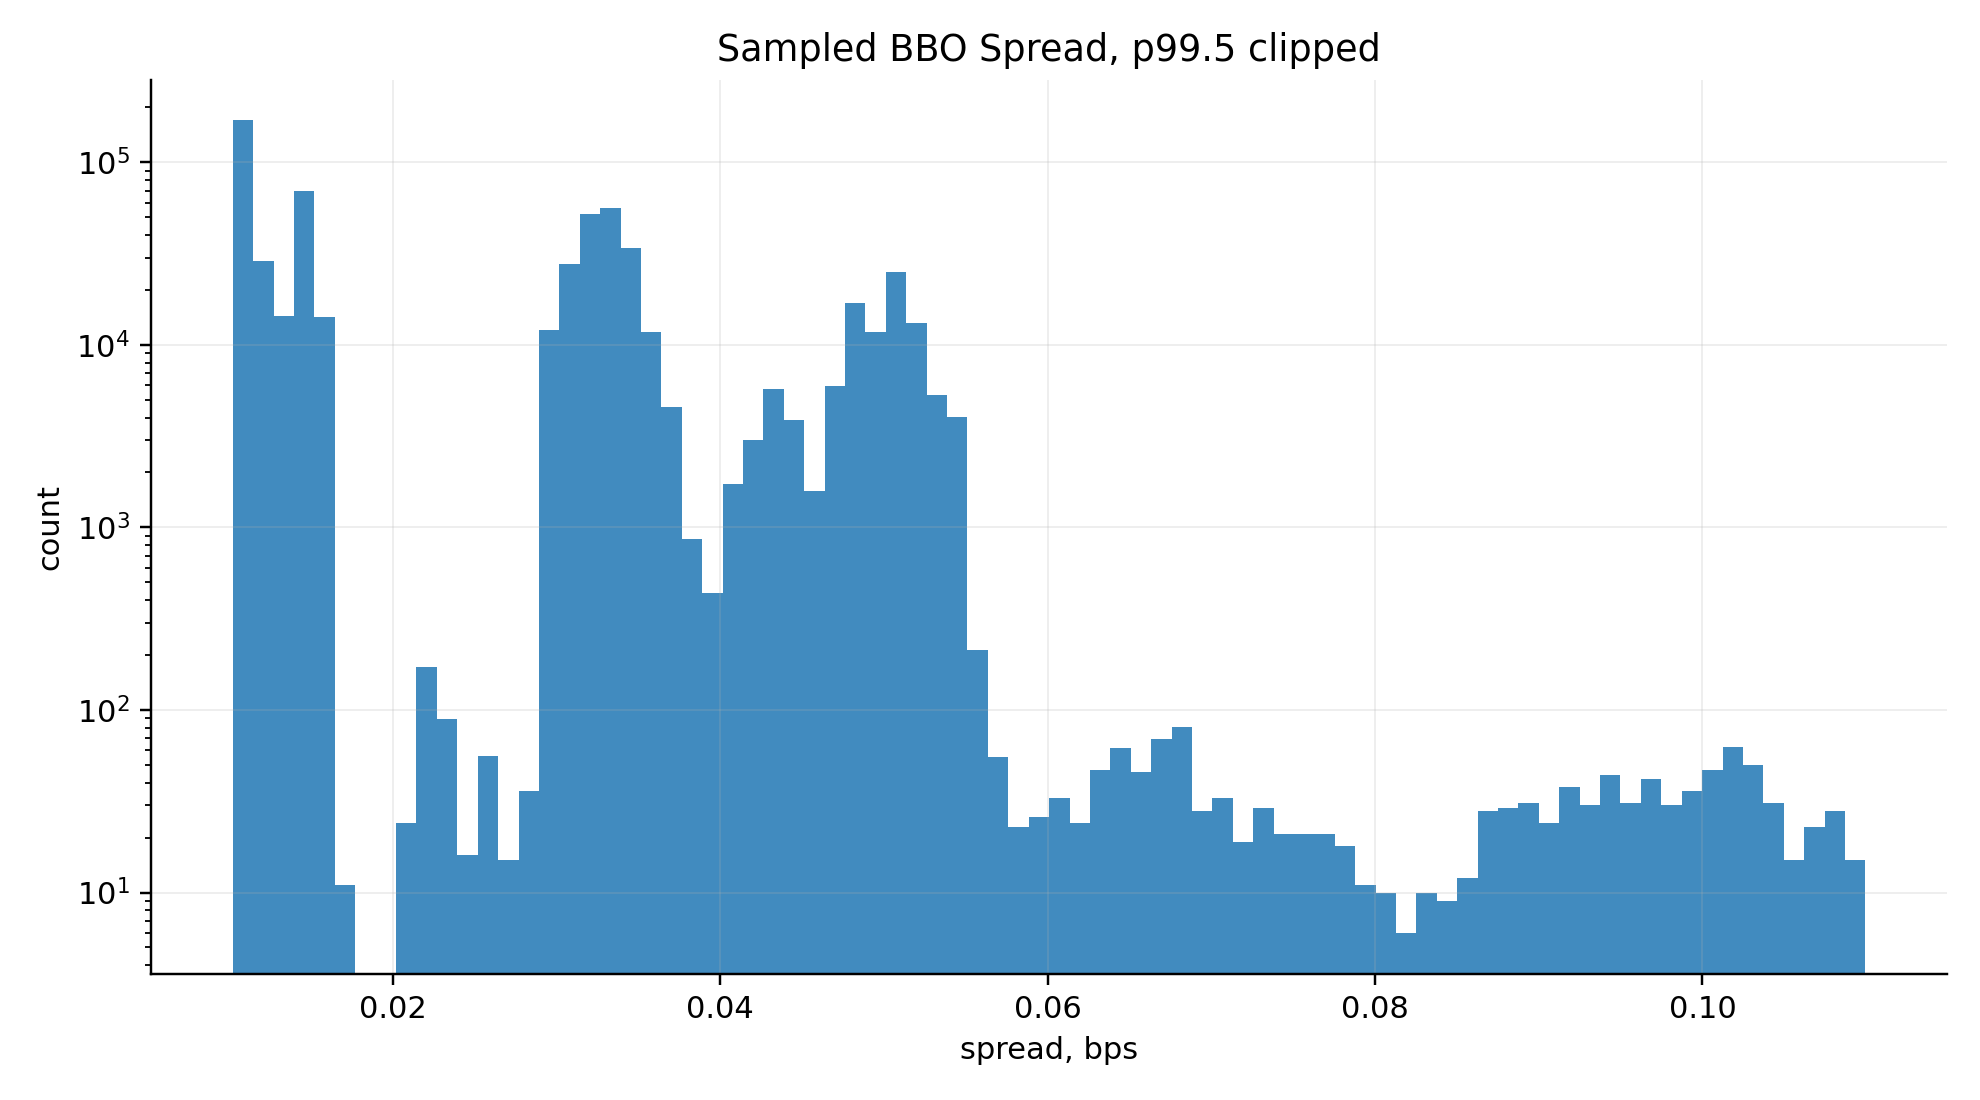

In [11]:
show_figure("spread_distribution_bps.png")

**Spread distribution.** Spreads are extremely tight in basis points,
which is expected for liquid BTCUSDT/ETHUSDT perpetuals.  The plot is
clipped in the far tail for readability; the clipped visualization is
descriptive only, while quality and markout tables are full-data.

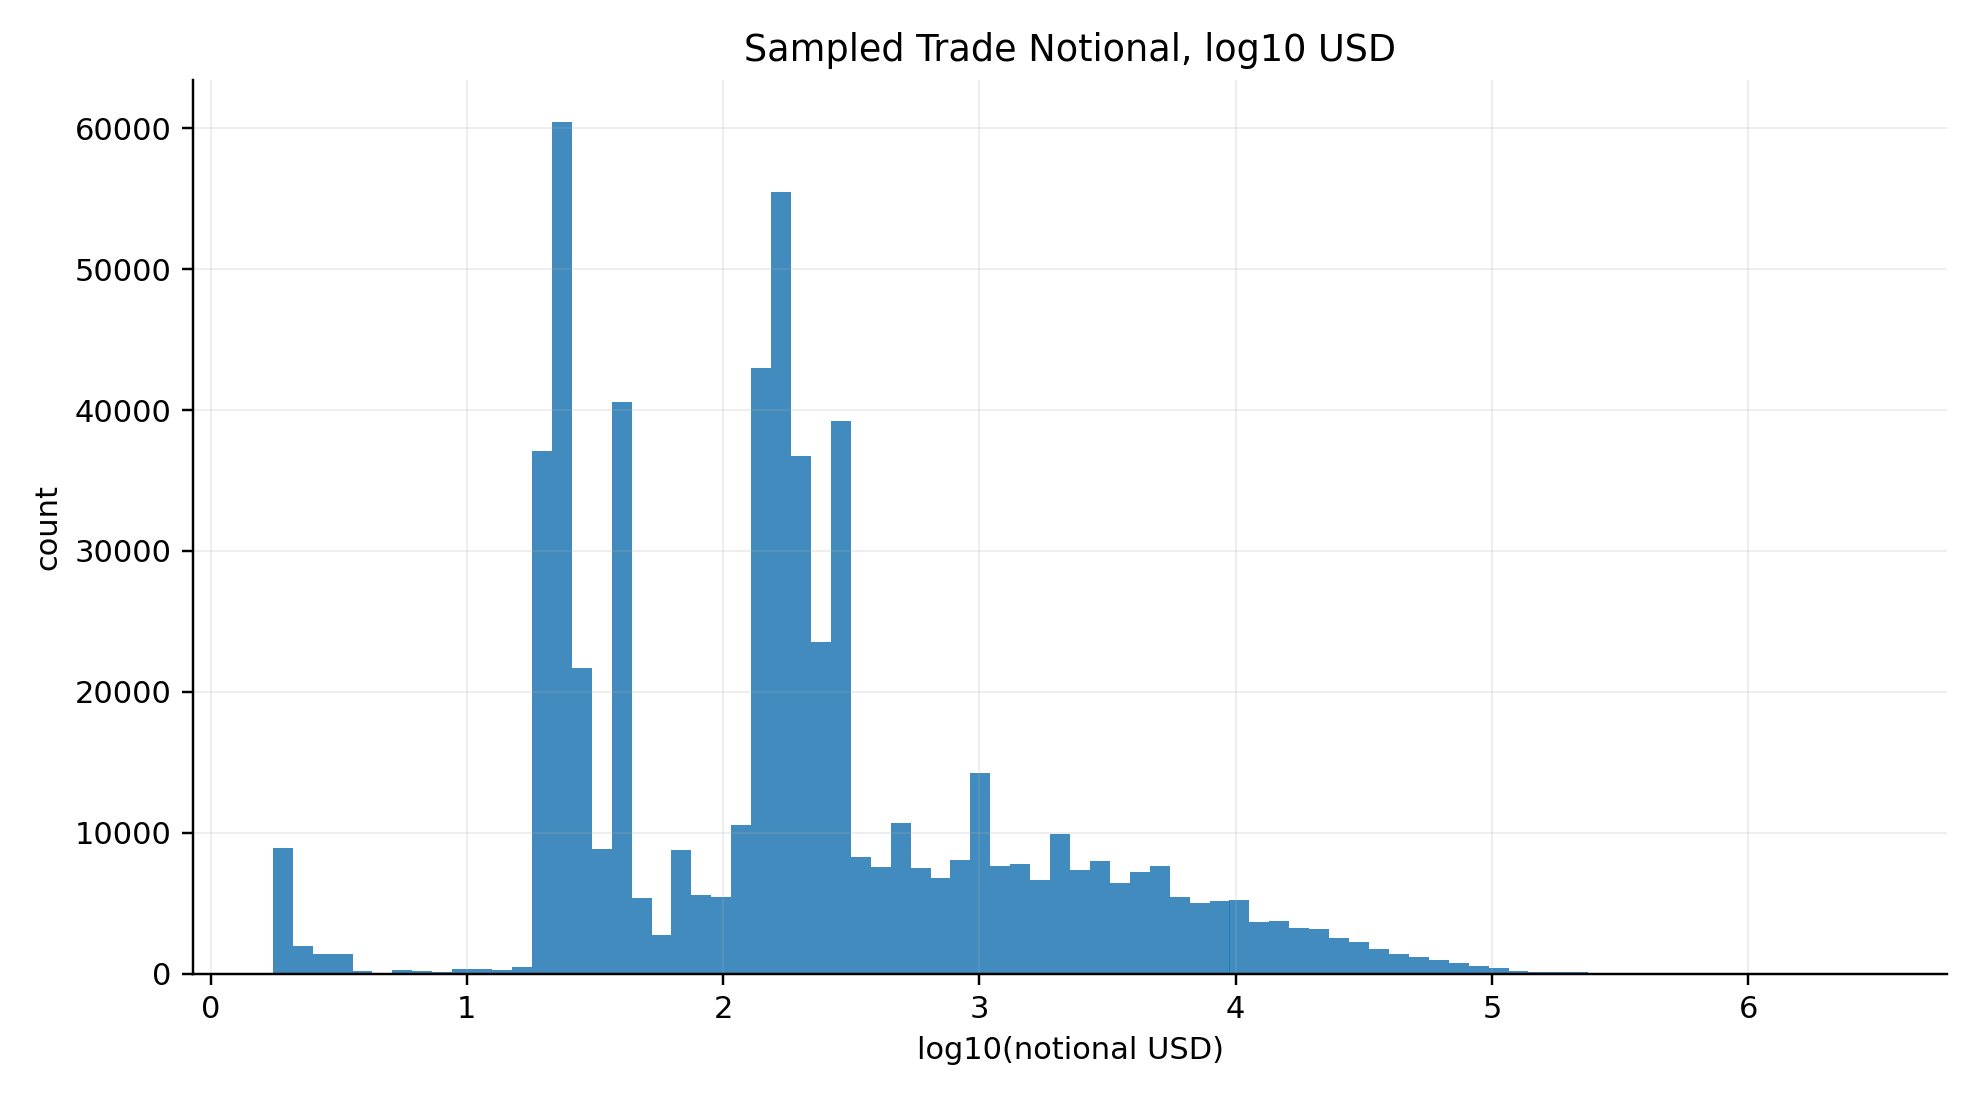

In [12]:
show_figure("trade_notional_distribution.png")

**Trade notional distribution.** Trade notionals are plotted on a
log scale because the distribution is strongly right-tailed.  This is
the reason the task uses clipped weights
`min(price * amount, 100000)`: without clipping, a small number of
very large prints could dominate weighted maker-PnL estimates.

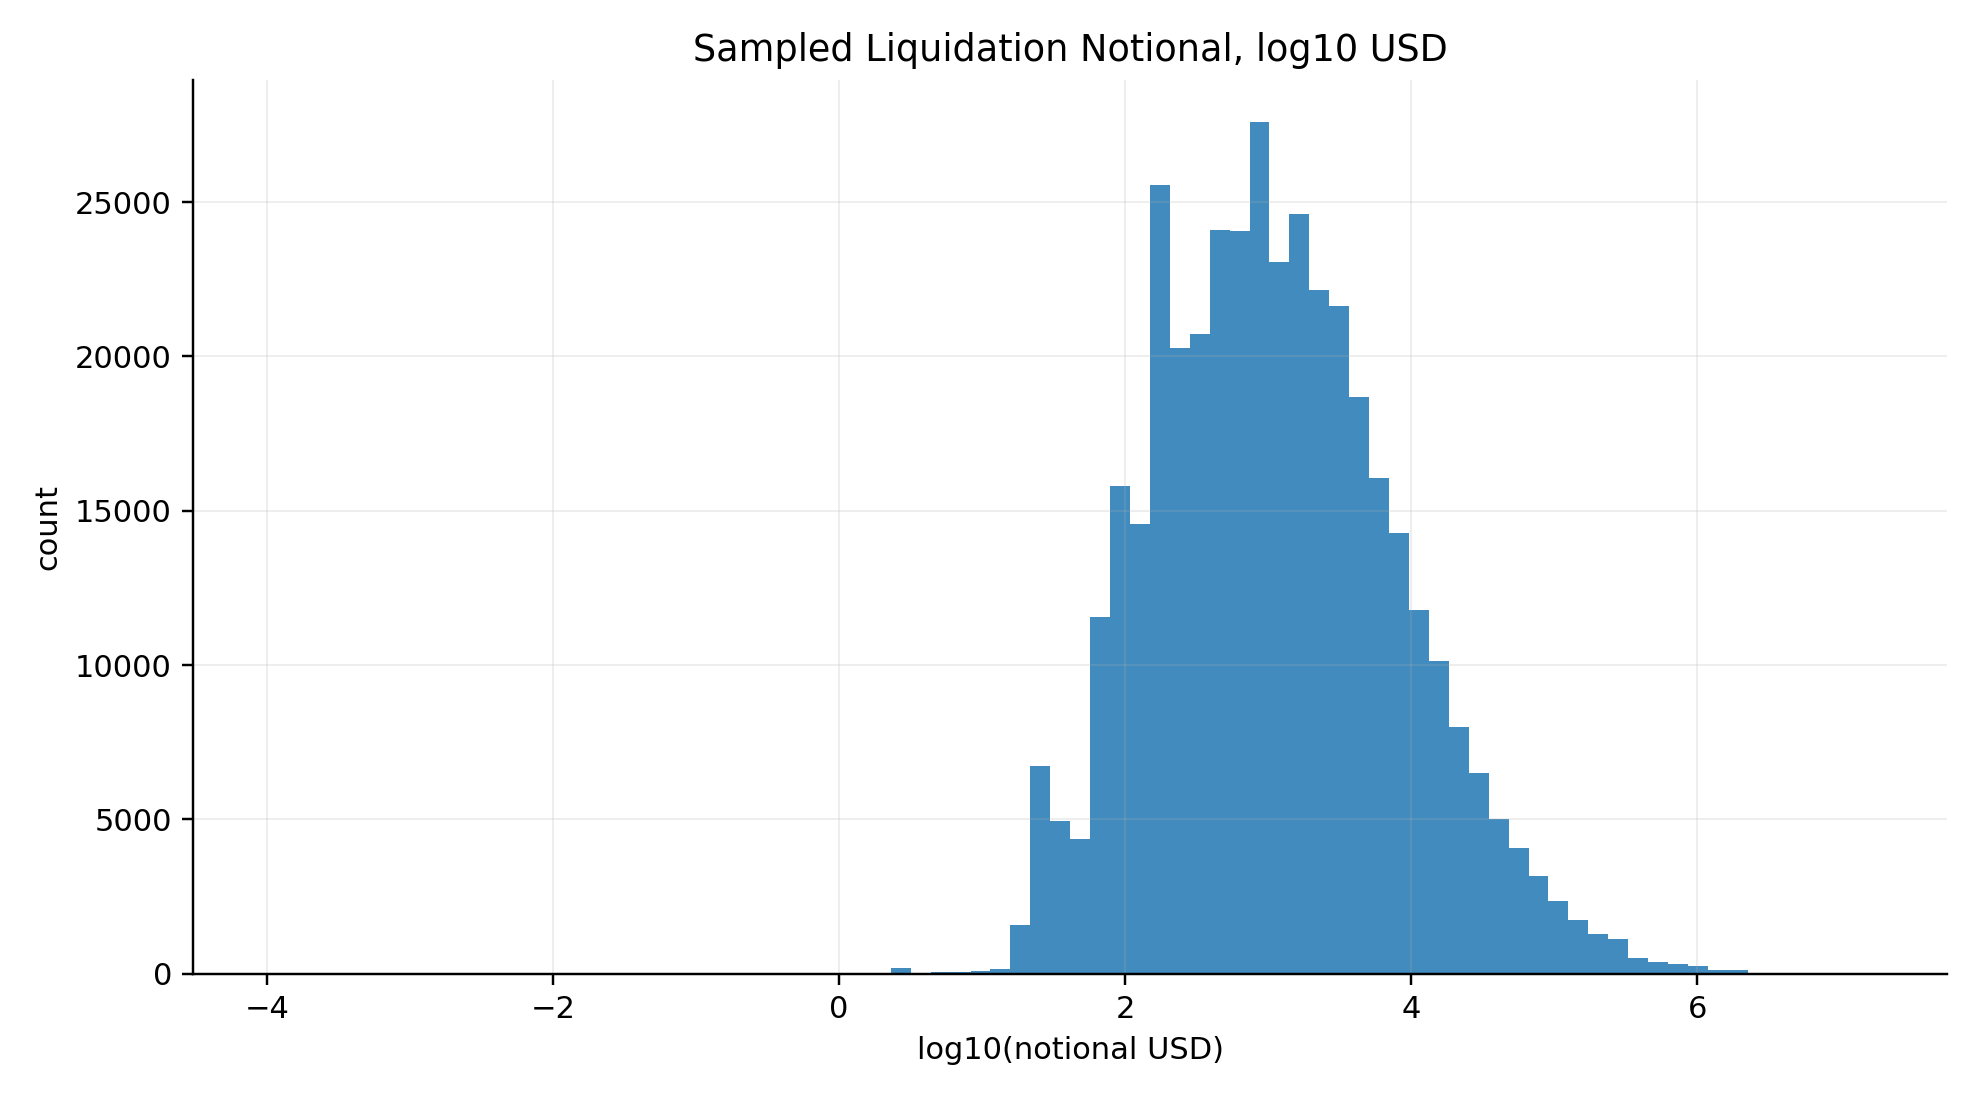

In [13]:
show_figure("liquidation_notional_distribution.png")

**Liquidation notional distribution.** Liquidations are much sparser
than trades but also heavy-tailed.  This motivates bucketed analyses:
small liquidation events and liquidation clusters should not be
treated as equivalent.

In [14]:
trade_summary = show_table("trade_summary.csv", n=16, title="Trade summary")
liquidation_summary = show_table("liquidation_summary.csv", n=16, title="Liquidation summary")

**Trade summary**

,split,date,symbol,side,rows,mean_amount,mean_notional,clipped_turnover
0,train,2025-12-01,btcusdt,buy,3391195,0.0435759,"3,752.16",1.13797e+10
1,train,2025-12-01,btcusdt,sell,3376672,0.0441464,"3,806.46",1.17047e+10
2,train,2025-12-02,btcusdt,buy,2692076,0.0430796,"3,851.49",9.44487e+09
3,train,2025-12-02,btcusdt,sell,2628288,0.0426619,"3,815.99",9.20266e+09
4,train,2025-12-03,btcusdt,buy,2728280,0.0372867,"3,460.07",8.62804e+09
5,train,2025-12-03,btcusdt,sell,2706619,0.0367869,"3,412.24",8.455e+09
6,train,2025-12-04,btcusdt,buy,2069849,0.0347616,"3,221.17",6.29359e+09
7,train,2025-12-04,btcusdt,sell,2094053,0.0357303,"3,309.43",6.44082e+09
8,train,2025-12-05,btcusdt,buy,2239362,0.0395576,"3,570.6",7.32593e+09
9,train,2025-12-05,btcusdt,sell,2275904,0.0397823,"3,589.97",7.45369e+09


`trade_summary.csv`: 360 rows, 8 columns.

**Liquidation summary**

,split,date,venue,symbol,side,rows,mean_notional,notional_sum,clipped_turnover
0,train,2025-12-01,binance,btcusdt,buy,963,"8,594.7",8.2767e+06,7.31144e+06
1,train,2025-12-01,binance,btcusdt,sell,1959,"10,922.4",2.1397e+07,1.45395e+07
2,train,2025-12-01,bybit,btcusdt,buy,1016,"11,048.8",1.12256e+07,7.09393e+06
3,train,2025-12-01,bybit,btcusdt,sell,6026,"13,640.6",8.21982e+07,4.45952e+07
4,train,2025-12-02,binance,btcusdt,buy,1094,"9,260.18",1.01306e+07,8.24841e+06
5,train,2025-12-02,binance,btcusdt,sell,551,"7,194.98",3.96443e+06,3.12774e+06
6,train,2025-12-02,bybit,btcusdt,buy,2629,"12,587.7",3.3093e+07,2.08702e+07
7,train,2025-12-02,bybit,btcusdt,sell,396,"7,934.86",3.1422e+06,2.31181e+06
8,train,2025-12-03,binance,btcusdt,buy,1126,"10,807.5",1.21693e+07,7.82583e+06
9,train,2025-12-03,binance,btcusdt,sell,641,"8,399.83",5.38429e+06,4.43205e+06


`liquidation_summary.csv`: 720 rows, 9 columns.

In [15]:
liq_daily = (
    daily_counts[daily_counts["source"].str.contains("liquidations")]
    .groupby(["date", "symbol"], as_index=False)["rows"].sum()
    .rename(columns={"rows": "liquidation_rows"})
)
trade_daily = (
    daily_counts[daily_counts["source"].eq("binance_trades")]
    .groupby(["date", "symbol"], as_index=False)["rows"].sum()
    .rename(columns={"rows": "trade_rows"})
)
daily_activity = trade_daily.merge(liq_daily, on=["date", "symbol"], how="left").fillna({"liquidation_rows": 0})
daily_activity["liquidations_per_million_trades"] = (
    daily_activity["liquidation_rows"] / daily_activity["trade_rows"] * 1_000_000
)
display(daily_activity.sort_values("liquidations_per_million_trades", ascending=False).head(12))

,date,symbol,trade_rows,liquidation_rows,liquidations_per_million_trades
122,2026-01-31,btcusdt,7436381,16765,"2,254.46"
110,2026-01-25,btcusdt,2890811,4594,"1,589.17"
100,2026-01-20,btcusdt,4631076,7247,"1,564.86"
132,2026-02-05,btcusdt,19580992,29960,"1,530.06"
0,2025-12-01,btcusdt,6767867,9964,"1,472.25"
118,2026-01-29,btcusdt,5246035,7649,"1,458.05"
26,2025-12-14,btcusdt,2328825,3177,"1,364.21"
28,2025-12-15,btcusdt,4934205,6119,"1,240.12"
96,2026-01-18,btcusdt,1329656,1632,"1,227.39"
120,2026-01-30,btcusdt,7256125,8607,"1,186.17"


**Alpha-search read.** Liquidations should not be treated only as
another volume field.  The interesting object is forced flow relative
to normal trade activity: high liquidation-per-trade days are
candidates for stress regimes where passive fills are more toxic and
continuation/reversal patterns can differ from ordinary flow.  This
motivates features such as recent liquidation pressure divided by
recent trade notional or BBO update rate, not just raw liquidation
notional.

## 4. Order Book State: Queue Imbalance and OFI

This block asks whether the book contains short-horizon directional
information.  Two classical microstructure quantities are used:

- queue imbalance: bid size / (bid size + ask size);
- order-flow imbalance (OFI): signed change in top-of-book pressure.

These are not trading signals yet; they are diagnostics for whether
the market state is informative.

In [16]:
qi = read_table("queue_imbalance_next_move.csv")
qi_pivot = qi.pivot_table(
    index=["split", "symbol"],
    values=["prob_next_move_up", "no_mid_move_share"],
    aggfunc=["min", "max", "mean"],
)
display(qi.head(20))
display(qi_pivot)

,split,symbol,imbalance_bucket,rows,mean_queue_imbalance,prob_next_move_up,prob_next_move_down,prob_next_event_up,prob_next_event_down,no_mid_move_share
0,train,btcusdt,1,7920558,0.035475,0.0140481,0.985952,0.00275738,0.193524,0.803719
1,train,btcusdt,2,6507789,0.152352,0.0583158,0.941684,0.00213437,0.0344658,0.9634
2,train,btcusdt,3,6667560,0.249044,0.137137,0.862863,0.00304789,0.0191773,0.977775
3,train,btcusdt,4,5814953,0.348689,0.269261,0.730739,0.00464217,0.0125982,0.98276
4,train,btcusdt,5,5614610,0.450278,0.420241,0.579759,0.00635503,0.00876731,0.984878
5,train,btcusdt,6,5623555,0.549645,0.567196,0.432804,0.00854513,0.00652043,0.984934
6,train,btcusdt,7,5852607,0.65138,0.723178,0.276822,0.0123162,0.00471448,0.982969
7,train,btcusdt,8,6800085,0.751022,0.85957,0.14043,0.0183573,0.00299908,0.978644
8,train,btcusdt,9,6679555,0.847735,0.939735,0.0602653,0.0330446,0.00211915,0.964836
9,train,btcusdt,10,8172672,0.964053,0.985298,0.014702,0.188319,0.00280997,0.808871


min                                 max                                mean                  
                   no_mid_move_share prob_next_move_up no_mid_move_share prob_next_move_up no_mid_move_share prob_next_move_up
split      symbol                                                                                                             
train      btcusdt          0.803719         0.0140481          0.984934          0.985298          0.943279          0.497398
           ethusdt          0.821565          0.027224          0.971767          0.971845          0.935093          0.495139
validation btcusdt          0.761537          0.024507          0.956698           0.97473          0.911805          0.496147
           ethusdt          0.733764         0.0458994          0.934332          0.952032          0.886607          0.493714

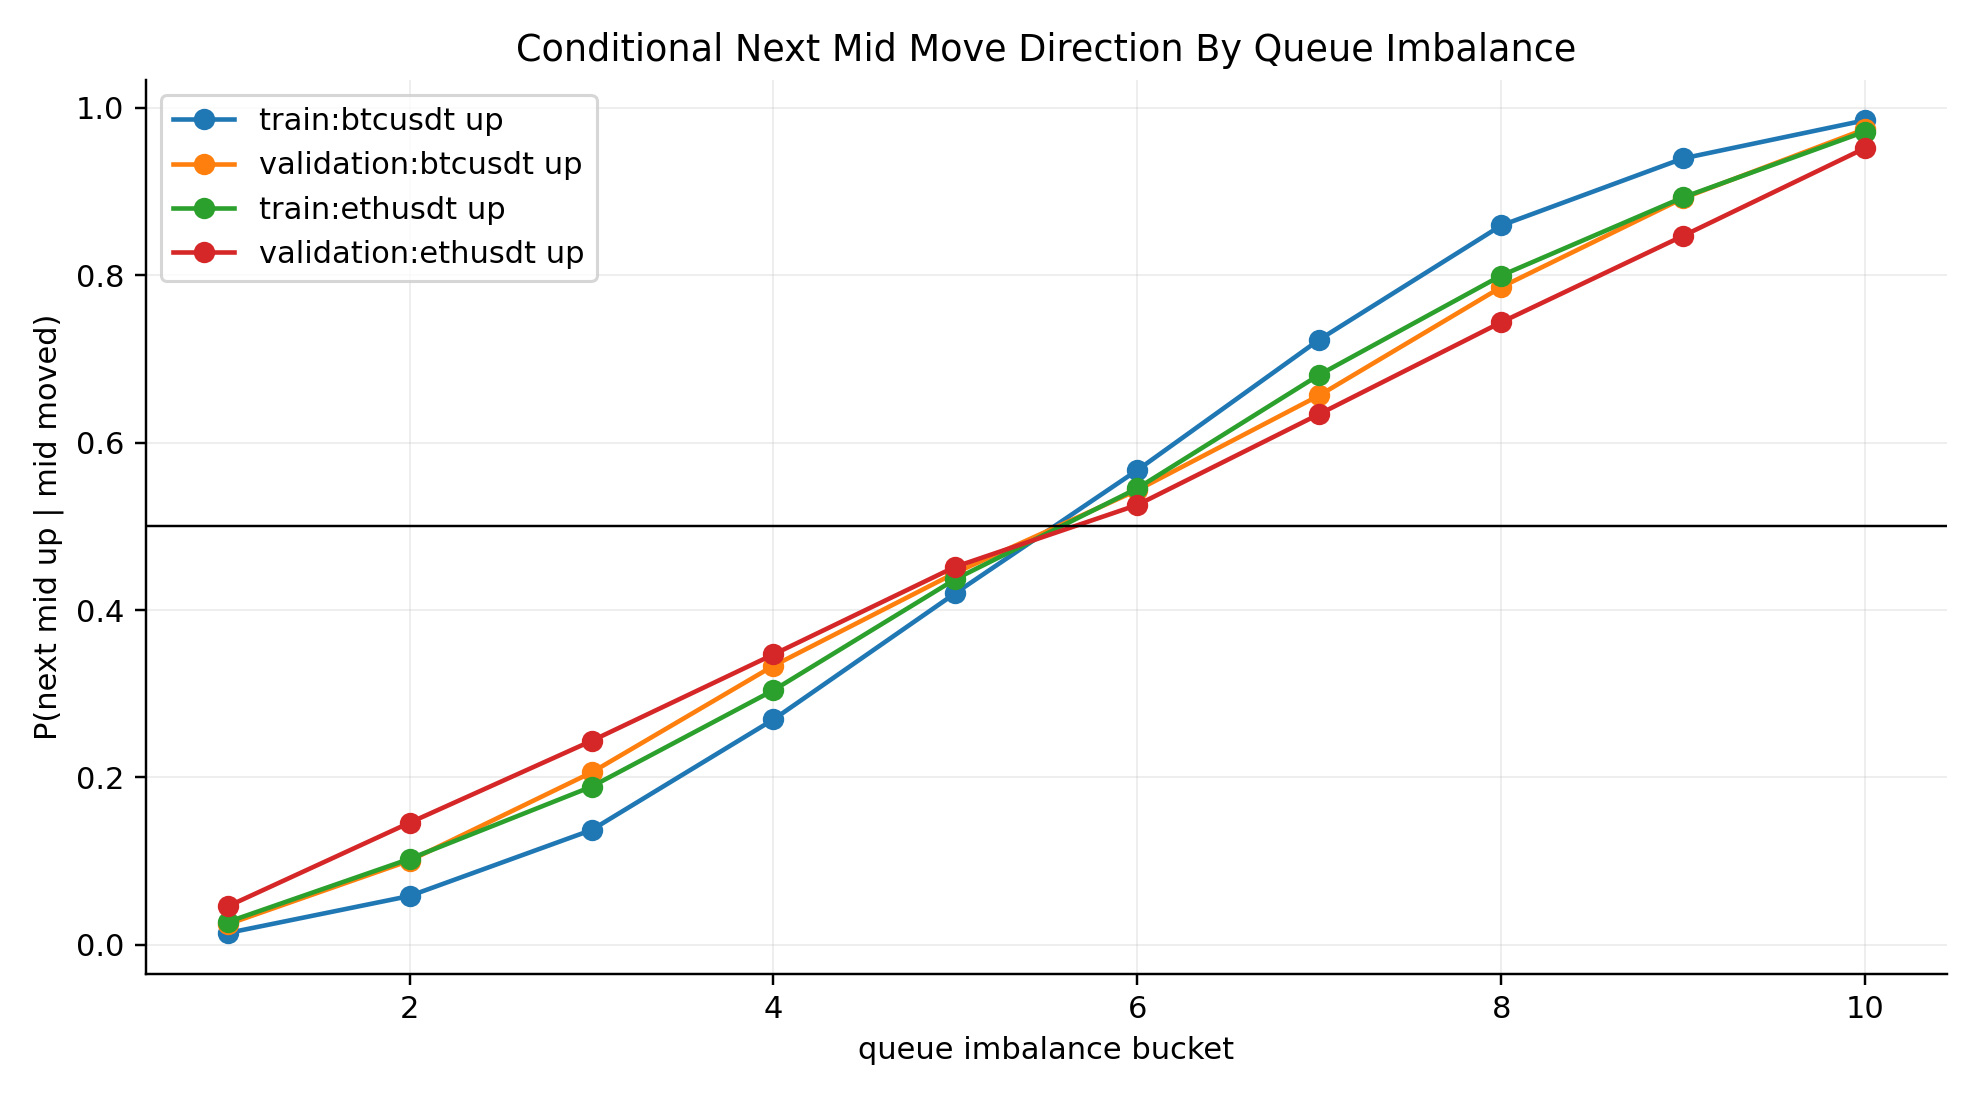

In [17]:
show_figure("queue_imbalance_next_move_probability.png")

**Queue imbalance finding.** Conditional on a mid-price move
occurring at the next BBO event, the probability of an upward move is
monotonic in queue imbalance.  Low bid-side queue share predicts
downward moves; high bid-side queue share predicts upward moves.
Most consecutive BBO events do not move the mid-price, so the plot
distinguishes `P(next mid up | mid moved)` from raw next-event
probabilities.

In [18]:
ofi = show_table("bbo_ofi_summary.csv", n=8, title="OFI summary")

**OFI summary**

,split,symbol,rows,mean_ofi,mean_next_return_bps,corr_ofi_next_return_bps
0,train,btcusdt,65653944,0.0040324,-2.0041e-05,0.445001
1,validation,btcusdt,33515443,0.00181047,-4.56892e-05,0.445413
2,train,ethusdt,72539958,0.040761,-2.4975e-05,0.420065
3,validation,ethusdt,35256988,0.0854701,-5.58263e-05,0.427037


`bbo_ofi_summary.csv`: 4 rows, 6 columns.

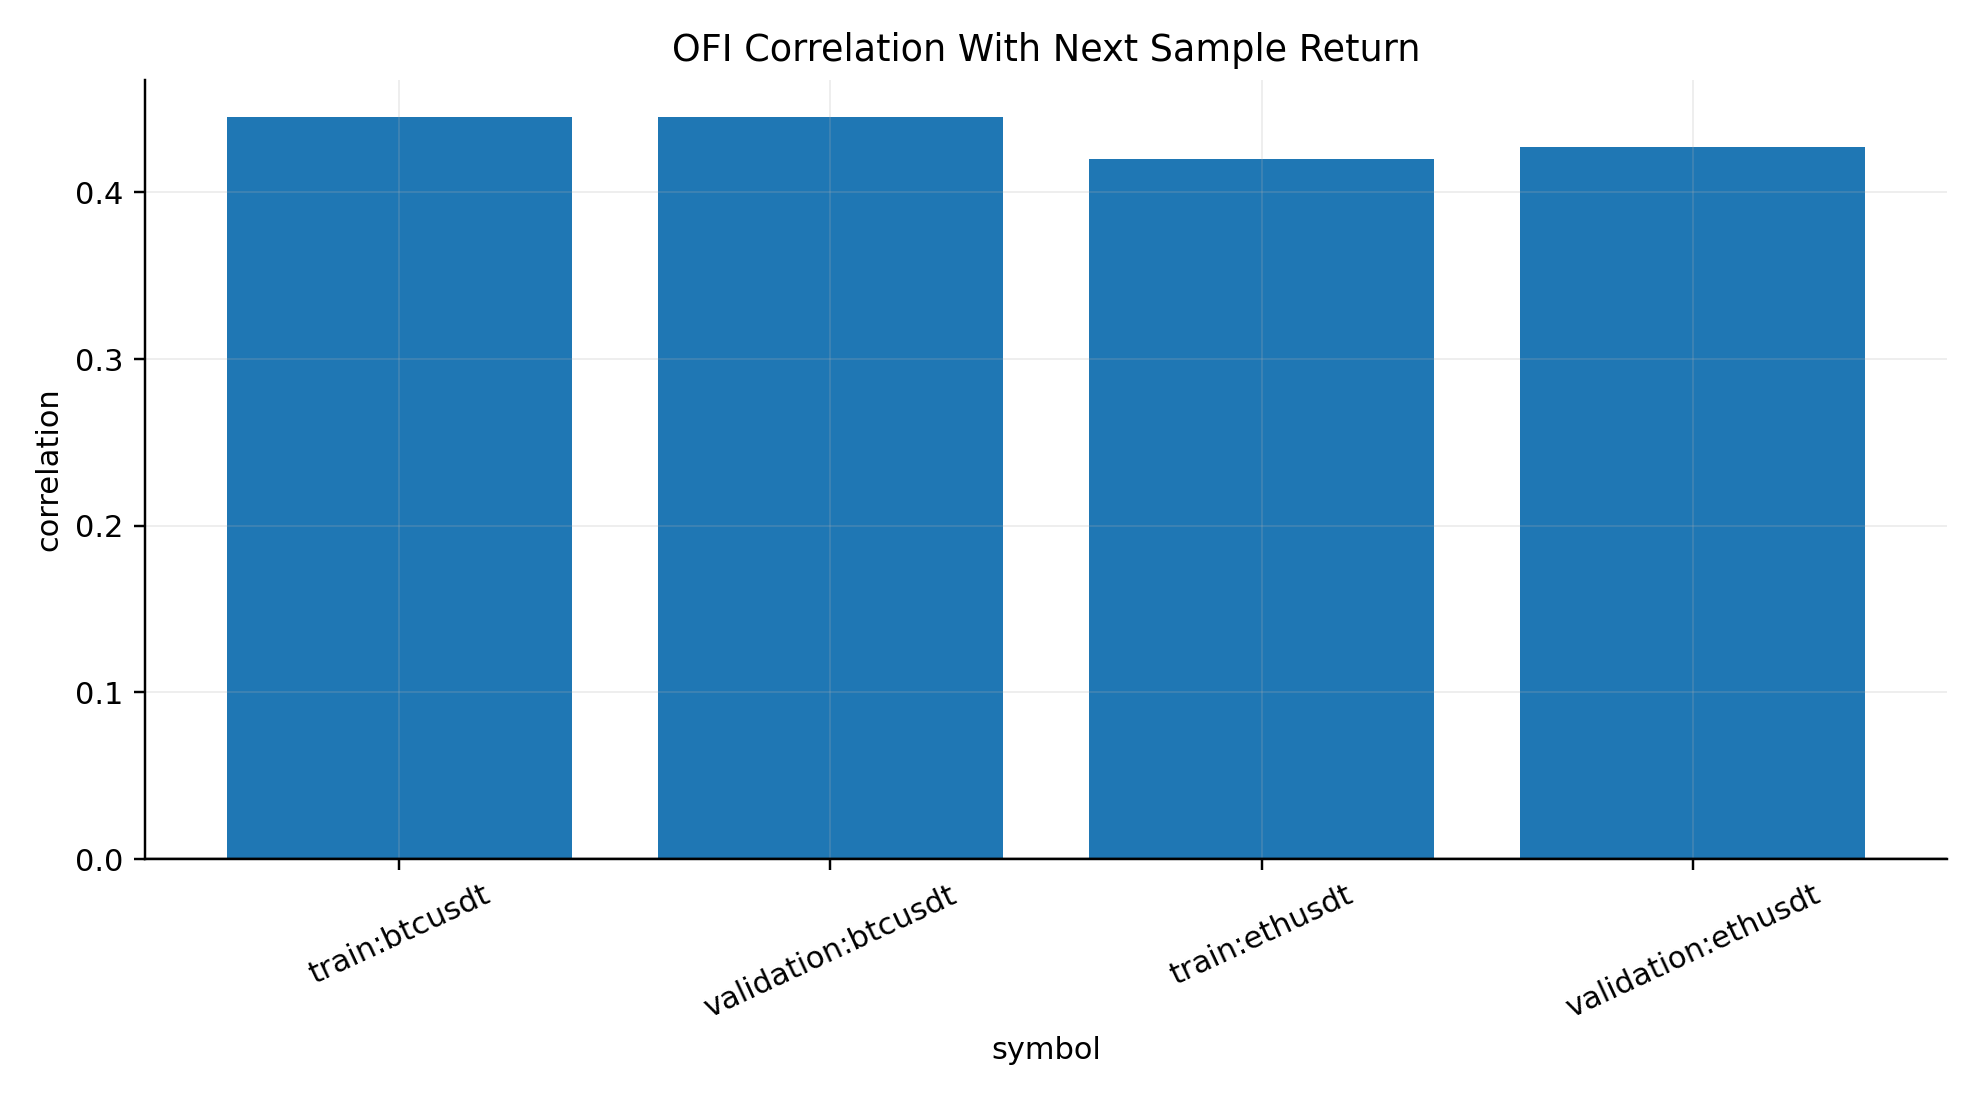

In [19]:
show_figure("ofi_vs_future_return.png")

**OFI finding.** OFI has a positive same-direction relationship with
next BBO returns in both symbols and both splits.  This is consistent
with Cont-Kukanov-Stoikov style intuition: changes in displayed
queue pressure are informative about short-horizon price formation.

## 5. Baseline Maker Markout

The task's maker-PnL markout is:

$$
\operatorname{pnl}_i(\tau) =
-s_i \frac{m_i(\tau)-p_i}{p_i} \cdot 10000
+ \operatorname{maker\_rebate\_bps}
$$

where `s_i = +1` for taker buy / maker sell and `s_i = -1` for
taker sell / maker buy.  This is a diagnostic for adverse selection:
after a trade, did the future mid move against the passive maker?

In [20]:
markout = read_table("full_markout_summary.csv")
display(markout)
best = markout.sort_values("weighted_pnl_bps", ascending=False).head(8)
worst = markout.sort_values("weighted_pnl_bps", ascending=True).head(8)
display(Markdown("**Best full-data markout buckets**"))
display(best)
display(Markdown("**Worst full-data markout buckets**"))
display(worst)

,split,symbol,side,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
0,train,btcusdt,buy,1,105270903,3.43246e+11,-0.0823119,-0.123673
1,train,btcusdt,sell,1,106093737,3.47872e+11,-0.0395508,-0.105353
2,train,btcusdt,buy,5,105270499,3.43245e+11,-0.174364,-0.236101
3,train,btcusdt,sell,5,106093078,3.47871e+11,-0.0965946,-0.210537
4,train,btcusdt,buy,10,105269502,3.43242e+11,-0.214771,-0.27071
5,train,btcusdt,sell,10,106091618,3.47866e+11,-0.048748,-0.207585
6,train,btcusdt,buy,30,105263318,3.43222e+11,-0.233596,-0.265758
7,train,btcusdt,sell,30,106083728,3.47838e+11,0.0215217,-0.186182
8,train,btcusdt,buy,60,105259438,3.43189e+11,-0.162365,-0.218715
9,train,btcusdt,sell,60,106073417,3.47778e+11,0.105775,-0.160846


**Best full-data markout buckets**

,split,symbol,side,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
54,validation,ethusdt,buy,300,158333282,1.74757e+11,0.753097,0.222807
39,train,ethusdt,sell,120,194840621,3.40885e+11,0.451369,-0.145335
12,train,btcusdt,buy,300,105272115,3.43249e+11,0.338131,0.174077
49,validation,ethusdt,sell,30,158535308,1.75626e+11,0.325333,-0.142475
26,validation,btcusdt,buy,300,95066763,2.04405e+11,0.29033,0.339462
37,train,ethusdt,sell,60,194837346,3.40881e+11,0.288427,-0.104894
52,validation,ethusdt,buy,120,158334331,1.74758e+11,0.254285,-0.00869061
47,validation,ethusdt,sell,10,158535627,1.75625e+11,0.233994,-0.127672


**Worst full-data markout buckets**

,split,symbol,side,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
27,validation,btcusdt,sell,300,95423900,2.05862e+11,-0.597991,-0.716783
25,validation,btcusdt,sell,120,95425594,2.05864e+11,-0.375281,-0.501929
36,train,ethusdt,buy,60,193984123,3.35489e+11,-0.293886,-0.189138
55,validation,ethusdt,sell,300,158534270,1.75624e+11,-0.279806,-0.414217
18,validation,btcusdt,buy,10,95071408,2.04416e+11,-0.277233,-0.307492
23,validation,btcusdt,sell,60,95425576,2.05862e+11,-0.263846,-0.388347
13,train,btcusdt,sell,300,106089556,3.47857e+11,-0.263543,-0.522384
34,train,ethusdt,buy,30,193987393,3.35499e+11,-0.254847,-0.220233


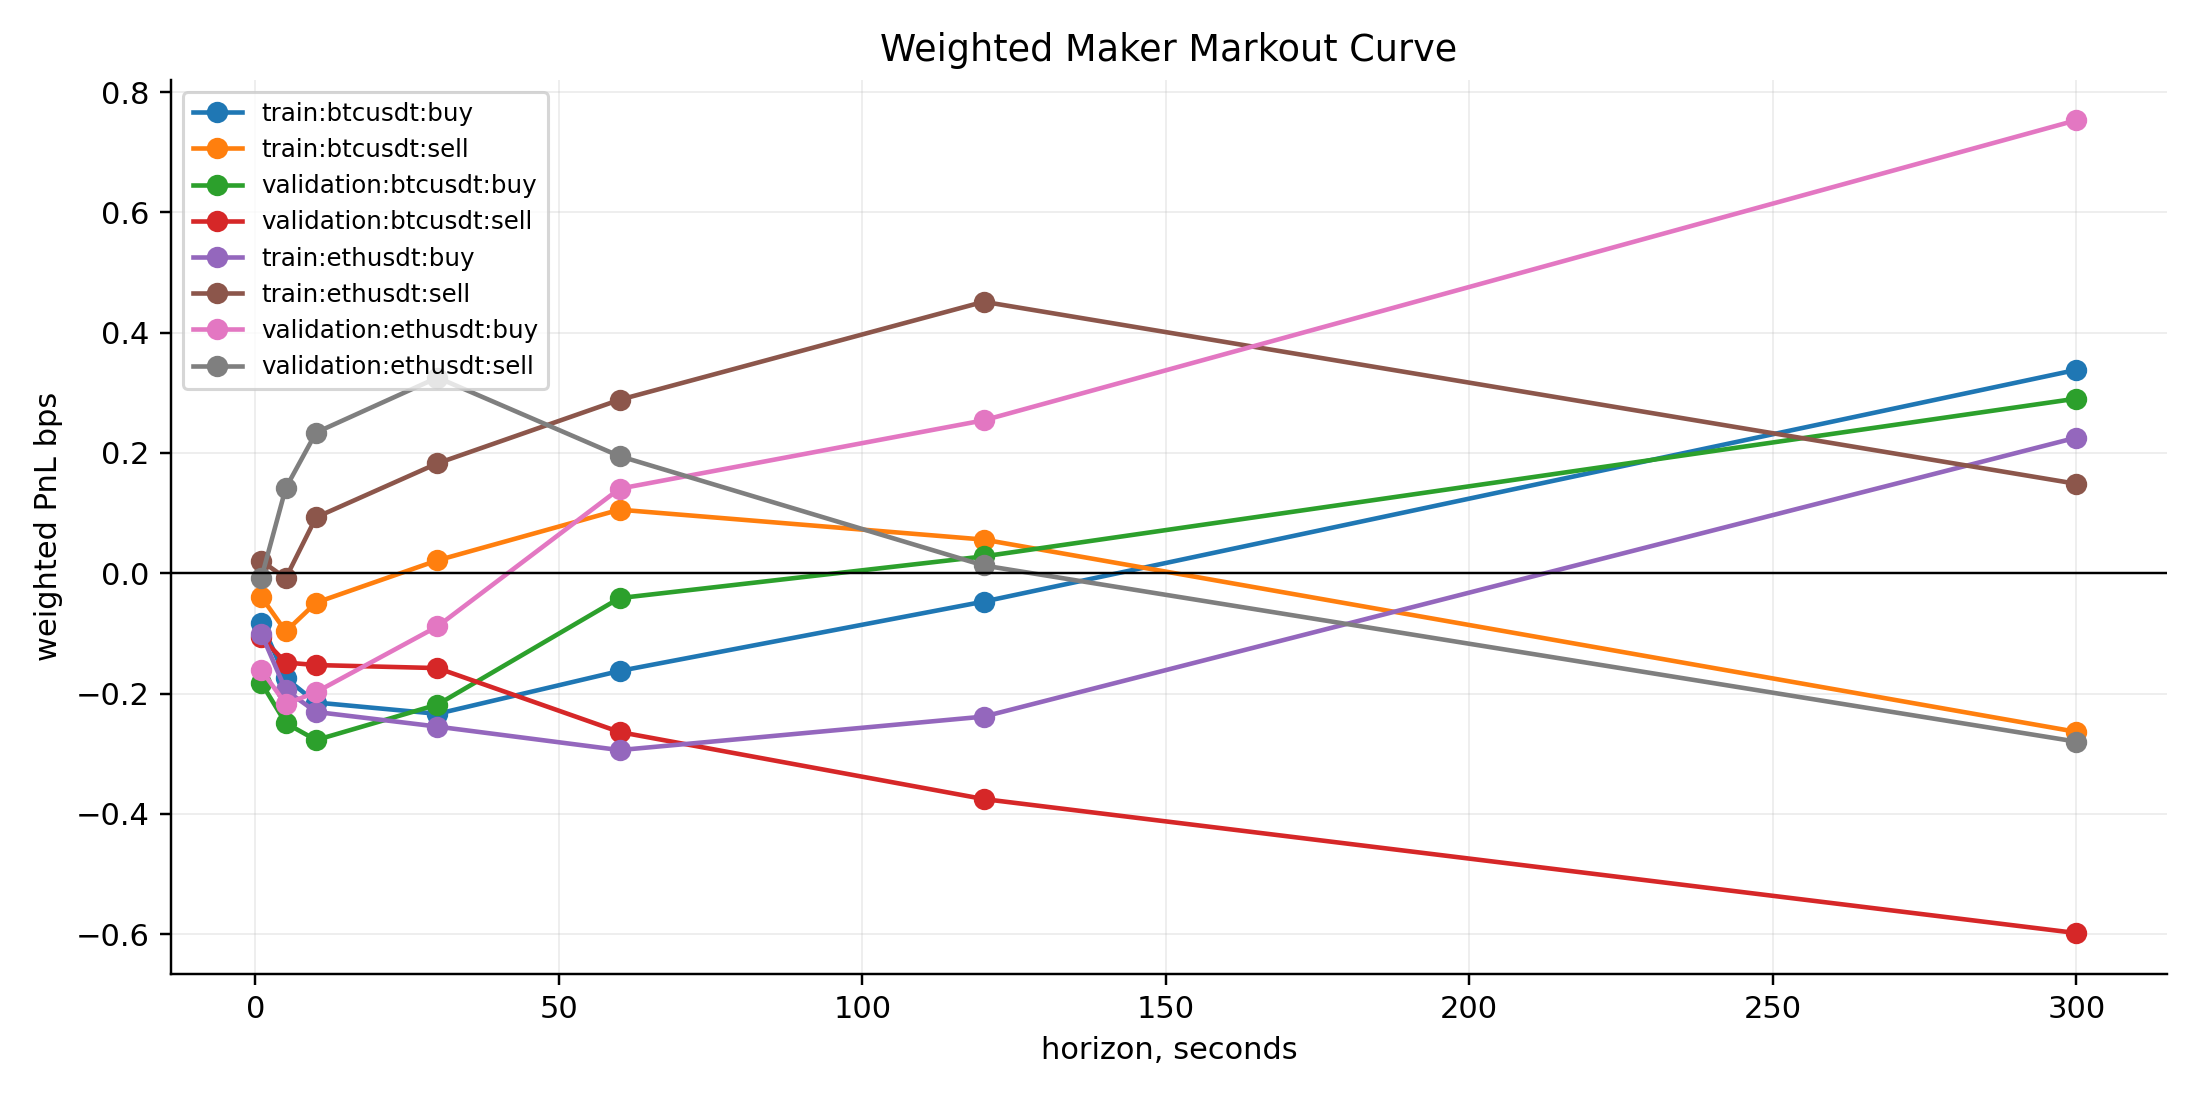

In [21]:
show_figure("markout_curve_by_side_symbol.png")

**Markout curve interpretation.** Markouts are small in absolute bps
terms but economically meaningful at HFT scale.  The curves differ
by symbol, side, horizon, and split.  This means a future filter
should not assume a single universal effect: side, horizon and asset
matter.

In [22]:
stability = (
    markout.pivot_table(
        index=["symbol", "side", "horizon_seconds"],
        columns="split",
        values="weighted_pnl_bps",
        aggfunc="first",
    )
    .reset_index()
)
if {"train", "validation"}.issubset(stability.columns):
    stability["validation_minus_train_bps"] = stability["validation"] - stability["train"]
    stability["same_sign"] = (stability["train"] * stability["validation"]) > 0
display(stability.sort_values("horizon_seconds").head(28))

split,symbol,side,horizon_seconds,train,validation,validation_minus_train_bps,same_sign
0,btcusdt,buy,1,-0.0823119,-0.182477,-0.100165,True
21,ethusdt,sell,1,0.0204293,-0.00714294,-0.0275723,False
14,ethusdt,buy,1,-0.100624,-0.160903,-0.0602787,True
7,btcusdt,sell,1,-0.0395508,-0.106512,-0.0669617,True
1,btcusdt,buy,5,-0.174364,-0.249042,-0.0746773,True
15,ethusdt,buy,5,-0.194236,-0.217302,-0.0230663,True
22,ethusdt,sell,5,-0.00809154,0.14161,0.149702,False
8,btcusdt,sell,5,-0.0965946,-0.14833,-0.0517358,True
16,ethusdt,buy,10,-0.230452,-0.197512,0.0329406,True
23,ethusdt,sell,10,0.0930597,0.233994,0.140934,True


**Researcher interpretation.** The raw maker markout is a baseline
toxicity map, not the final signal.  A positive bucket means a
passive maker would have benefited after those trades; a negative
bucket means adverse selection.  The important question is not
whether the average markout is positive everywhere, but where it is
predictably different from baseline and stable from train to
validation.  Buckets that flip sign between train and validation are
weak alpha candidates unless they can be explained by a regime
variable.

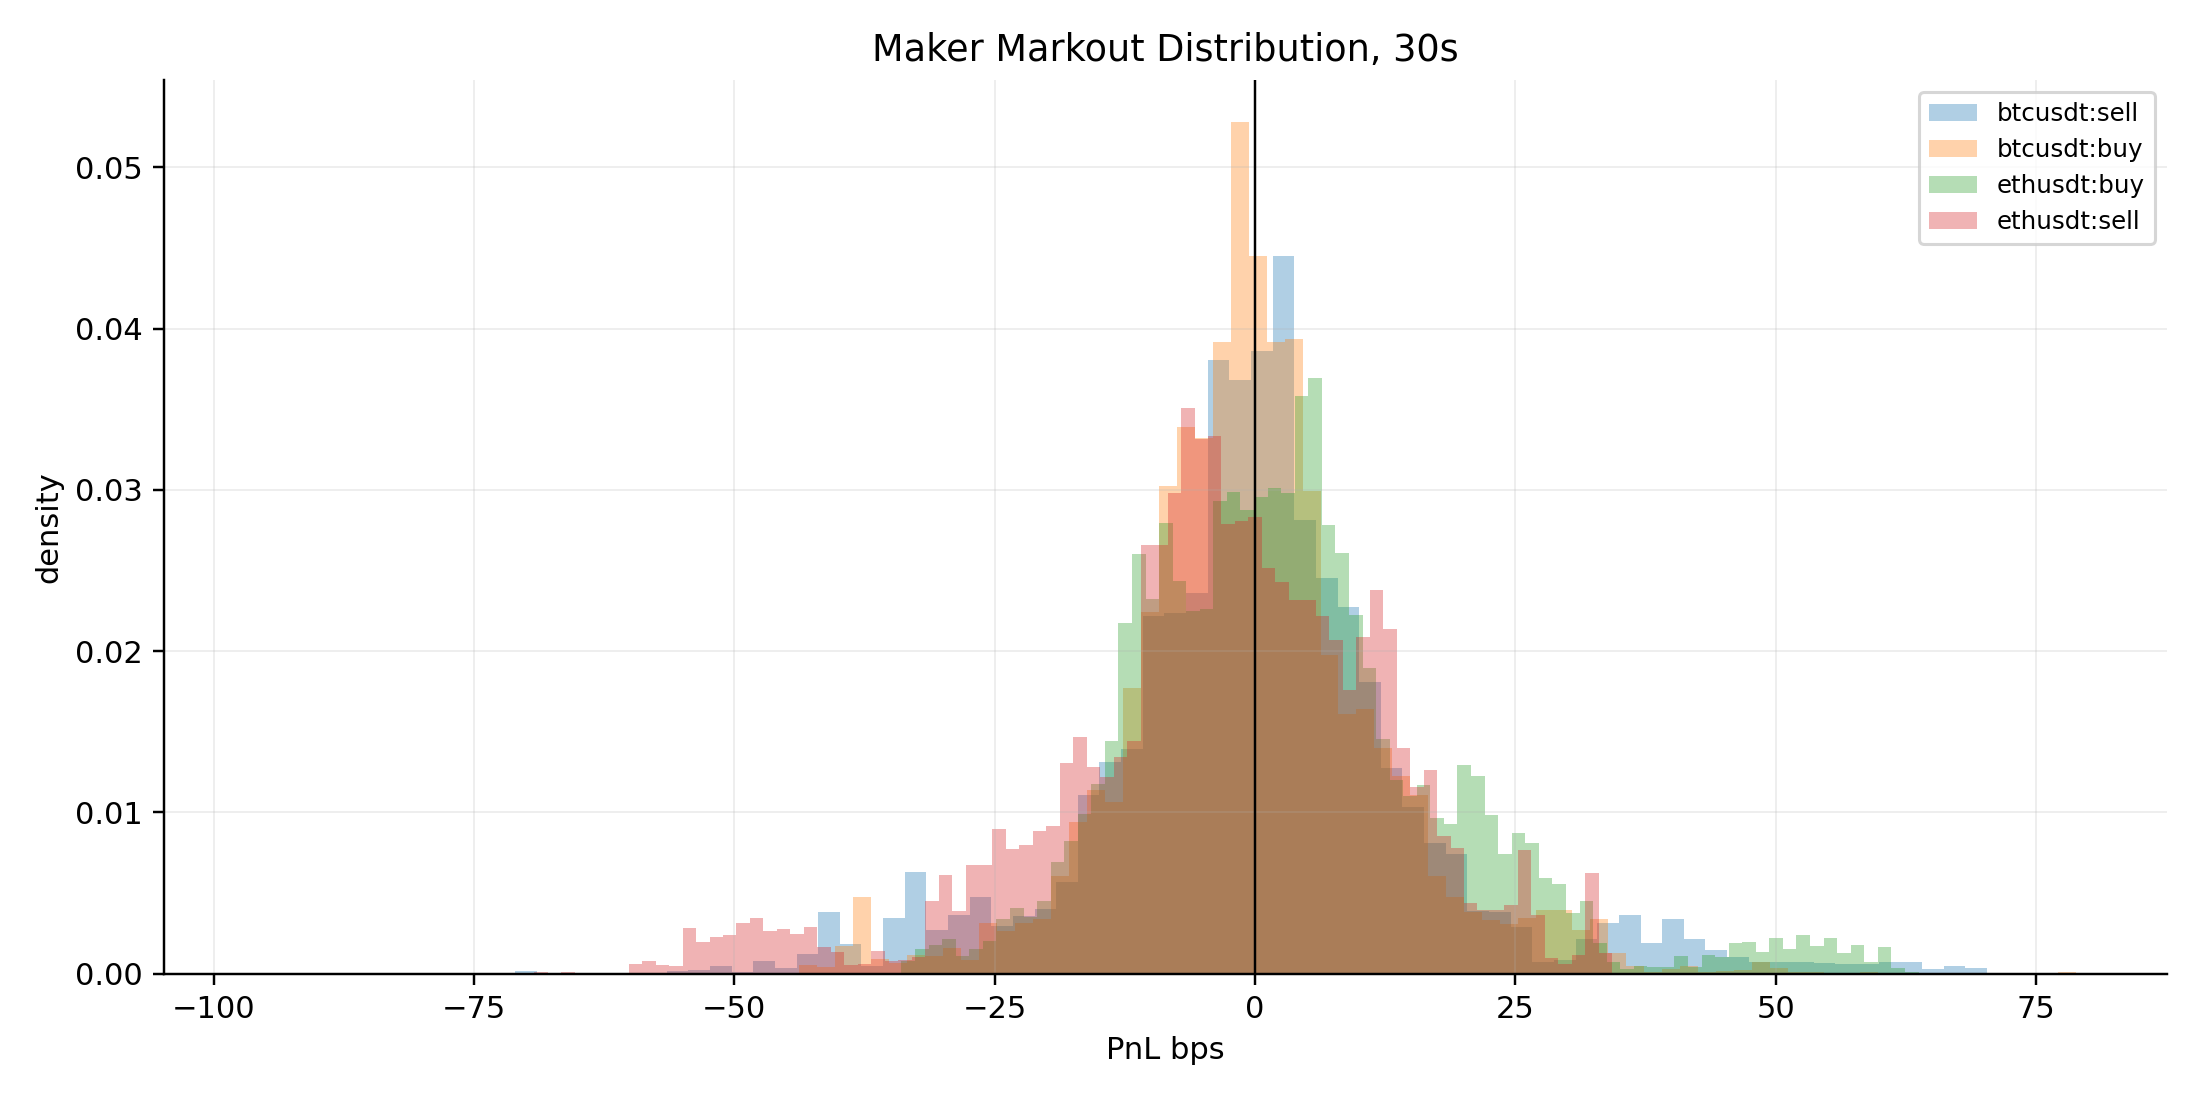

In [23]:
show_figure("markout_distribution_by_tau.png")

**Distribution interpretation.** The distribution plot highlights
tail risk around markouts.  Mean/weighted mean alone is not enough:
a strategy can look acceptable on average while being exposed to
occasional adverse-selection bursts.

In [24]:
daily_markout = read_table("full_daily_weighted_markout.csv")
daily_focus = daily_markout.query("horizon_seconds in [30, 120, 300]").head(20)
display(daily_focus)
display(Markdown(f"`full_daily_weighted_markout.csv`: {len(daily_markout):,} rows."))

,split,date,symbol,side,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
6,train,2025-12-01,btcusdt,buy,30,3391195,1.13797e+10,0.00859526,-0.0923593
7,train,2025-12-01,btcusdt,sell,30,3376672,1.17047e+10,0.0425738,-0.328087
10,train,2025-12-01,btcusdt,buy,120,3391195,1.13797e+10,0.936934,0.77864
11,train,2025-12-01,btcusdt,sell,120,3376672,1.17047e+10,-1.24547,-1.39934
12,train,2025-12-01,btcusdt,buy,300,3391195,1.13797e+10,3.19952,2.90684
13,train,2025-12-01,btcusdt,sell,300,3376672,1.17047e+10,-3.91954,-3.76019
20,train,2025-12-02,btcusdt,buy,30,2692076,9.44487e+09,-0.119871,-0.442539
21,train,2025-12-02,btcusdt,sell,30,2628288,9.20266e+09,0.226432,0.0840863
24,train,2025-12-02,btcusdt,buy,120,2692076,9.44487e+09,-0.48354,-1.07546
25,train,2025-12-02,btcusdt,sell,120,2628288,9.20266e+09,1.00474,1.05016


`full_daily_weighted_markout.csv`: 2,520 rows.

## 6. Liquidation Context

Now we test the key exploratory idea: liquidations may reveal forced
directional pressure.  Liquidation `side` is interpreted as
liquidation order side:

- `buy`: forced buy / short liquidation / upward pressure;
- `sell`: forced sell / long liquidation / downward pressure.

Binance liquidation context uses its event timestamp.  Bybit context
uses `available_timestamp = timestamp + 200_000`, because this is the
first time the event could be known in a Binance trading system.

In [25]:
context = read_table("full_markout_by_liquidation_context.csv")
focus_context = context[
    (context["horizon_seconds"].isin([30, 120, 300]))
    & (context["window_seconds"].isin([1, 5, 30, 120]))
].head(30)
display(focus_context)

,split,symbol,side,venue,window_seconds,liq_pressure_bucket,maker_vs_liq_pressure,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
0,train,btcusdt,buy,binance,1,downward_pressure,opposite_direction,30,3561639,1.42338e+10,-1.65167,-1.25941
1,train,btcusdt,buy,binance,1,no_pressure,none,30,97770378,3.09563e+11,-0.22019,-0.255349
2,train,btcusdt,buy,binance,1,upward_pressure,same_direction_toxic_risk,30,3931301,1.94252e+10,0.59184,0.375596
3,train,btcusdt,sell,binance,1,downward_pressure,same_direction_toxic_risk,30,5410081,2.7382e+10,2.29768,1.60013
4,train,btcusdt,sell,binance,1,no_pressure,none,30,97980518,3.09955e+11,-0.170249,-0.279328
5,train,btcusdt,sell,binance,1,upward_pressure,opposite_direction,30,2693129,1.05014e+10,-0.253263,-0.385767
6,train,btcusdt,buy,binance,5,downward_pressure,opposite_direction,30,8273420,3.07712e+10,-0.964583,-0.759743
7,train,btcusdt,buy,binance,5,no_pressure,none,30,88285471,2.72819e+11,-0.20715,-0.245049
8,train,btcusdt,buy,binance,5,upward_pressure,same_direction_toxic_risk,30,8704427,3.96312e+10,0.151914,-0.00627729
9,train,btcusdt,sell,binance,5,downward_pressure,same_direction_toxic_risk,30,10918505,5.06837e+10,1.44455,0.906717


**Liquidation context interpretation.** The table compares maker
markout conditional on recent upward/downward/no liquidation
pressure.  This is closer to a usable feature than raw event counts:
it asks whether the maker's future markout changes after a known
liquidation pressure regime.

In [26]:
baseline_context = (
    context[context["liq_pressure_bucket"].eq("no_pressure")]
    [["split", "symbol", "side", "venue", "window_seconds", "horizon_seconds", "weighted_pnl_bps"]]
    .rename(columns={"weighted_pnl_bps": "baseline_no_pressure_pnl_bps"})
)
context_edge = context.merge(
    baseline_context,
    on=["split", "symbol", "side", "venue", "window_seconds", "horizon_seconds"],
    how="left",
)
context_edge["edge_vs_no_pressure_bps"] = (
    context_edge["weighted_pnl_bps"] - context_edge["baseline_no_pressure_pnl_bps"]
)
robust_validation_edges = context_edge[
    (context_edge["split"].eq("validation"))
    & (~context_edge["liq_pressure_bucket"].eq("no_pressure"))
    & (context_edge["rows"] >= 1_000_000)
    & (context_edge["horizon_seconds"].isin([30, 120, 300]))
]
display(Markdown("**Largest positive validation edges vs no-pressure baseline**"))
display(robust_validation_edges.sort_values("edge_vs_no_pressure_bps", ascending=False).head(12))
display(Markdown("**Largest negative validation edges vs no-pressure baseline**"))
display(robust_validation_edges.sort_values("edge_vs_no_pressure_bps", ascending=True).head(12))

**Largest positive validation edges vs no-pressure baseline**

,split,symbol,side,venue,window_seconds,liq_pressure_bucket,maker_vs_liq_pressure,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps,baseline_no_pressure_pnl_bps,edge_vs_no_pressure_bps
968,validation,ethusdt,buy,bybit,1,upward_pressure,same_direction_toxic_risk,300,4328916,8.94871e+09,11.3889,8.93174,0.316338,11.0725
974,validation,ethusdt,buy,bybit,5,upward_pressure,same_direction_toxic_risk,300,9627139,1.74797e+10,8.57875,6.30857,0.0250425,8.5537
884,validation,ethusdt,buy,bybit,1,upward_pressure,same_direction_toxic_risk,120,4328916,8.94871e+09,8.00884,6.02982,0.0416636,7.96718
885,validation,ethusdt,sell,bybit,1,downward_pressure,same_direction_toxic_risk,120,6174011,1.25003e+10,7.32691,4.87906,-0.355626,7.68253
801,validation,ethusdt,sell,bybit,1,downward_pressure,same_direction_toxic_risk,30,6174535,1.25008e+10,7.32983,5.25915,-0.132904,7.46273
980,validation,ethusdt,buy,bybit,10,upward_pressure,same_direction_toxic_risk,300,13215417,2.23844e+10,7.04009,5.03383,-0.0456206,7.08571
969,validation,ethusdt,sell,bybit,1,downward_pressure,same_direction_toxic_risk,300,6174535,1.25008e+10,6.15849,4.19025,-0.473743,6.63223
926,validation,ethusdt,buy,binance,1,upward_pressure,same_direction_toxic_risk,300,7735619,1.37354e+10,7.02993,5.05238,0.406558,6.62337
890,validation,ethusdt,buy,bybit,5,upward_pressure,same_direction_toxic_risk,120,9627139,1.74797e+10,6.01626,4.32428,-0.125514,6.14177
891,validation,ethusdt,sell,bybit,5,downward_pressure,same_direction_toxic_risk,120,12949642,2.32164e+10,5.34638,3.16591,-0.527223,5.87361


**Largest negative validation edges vs no-pressure baseline**

,split,symbol,side,venue,window_seconds,liq_pressure_bucket,maker_vs_liq_pressure,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps,baseline_no_pressure_pnl_bps,edge_vs_no_pressure_bps
971,validation,ethusdt,sell,bybit,1,upward_pressure,opposite_direction,300,3197248,5.00722e+09,-10.2294,-8.49991,-0.473743,-9.75561
977,validation,ethusdt,sell,bybit,5,upward_pressure,opposite_direction,300,7667162,1.06418e+10,-6.84503,-6.07781,-0.571264,-6.27376
887,validation,ethusdt,sell,bybit,1,upward_pressure,opposite_direction,120,3197248,5.00722e+09,-6.60481,-5.56361,-0.355626,-6.24919
929,validation,ethusdt,sell,binance,1,upward_pressure,opposite_direction,300,5870594,7.87174e+09,-6.32497,-5.33925,-0.455267,-5.8697
983,validation,ethusdt,sell,bybit,10,upward_pressure,opposite_direction,300,10935673,1.44357e+10,-5.60624,-5.01437,-0.59763,-5.00861
798,validation,ethusdt,buy,bybit,1,downward_pressure,opposite_direction,30,4428115,7.09717e+09,-4.95515,-3.64807,-0.123218,-4.83194
882,validation,ethusdt,buy,bybit,1,downward_pressure,opposite_direction,120,4427803,7.0965e+09,-4.76898,-4.11229,0.0416636,-4.81064
467,validation,btcusdt,sell,bybit,1,upward_pressure,opposite_direction,300,2170469,5.86936e+09,-5.31199,-5.23819,-0.711369,-4.60062
935,validation,ethusdt,sell,binance,5,upward_pressure,opposite_direction,300,15049158,1.83991e+10,-4.49072,-4.04297,-0.577292,-3.91342
893,validation,ethusdt,sell,bybit,5,upward_pressure,opposite_direction,120,7667162,1.06418e+10,-4.42549,-4.1734,-0.527223,-3.89826


**Signal-design read.** This is where the EDA becomes actionable.
The useful object is the incremental edge versus a no-liquidation
baseline under the same symbol, side, venue, window and horizon.
Large positive edges suggest situations where the passive maker's
adverse selection is reduced or reversed; large negative edges
suggest toxic flow where a filter should avoid providing liquidity.
I would not trade the top rows directly; I would first require
train/validation stability, turnover capacity, and robustness across
neighboring windows.

In [27]:
nonlinear = read_table("nonlinear_flow_response.csv")
display(nonlinear.head(24))

,split,symbol,side,venue,window_seconds,signed_liq_bucket,horizon_seconds,rows,clipped_turnover,weighted_pnl_bps,mean_pnl_bps
0,train,btcusdt,buy,binance,1,zero,30,97770378,3.09563e+11,-0.22019,-0.255349
1,train,btcusdt,buy,binance,1,pos_1e2,30,1562121,7.44199e+09,1.07126,0.84237
2,train,btcusdt,buy,binance,1,pos_1e3,30,1618600,8.12482e+09,0.144797,-0.0789372
3,train,btcusdt,buy,binance,1,pos_1e4,30,613262,3.1318e+09,0.712791,0.420598
4,train,btcusdt,buy,binance,1,pos_1e5,30,107391,5.6962e+08,-0.269969,0.0272562
5,train,btcusdt,buy,binance,1,neg_1e1,30,34970,1.37338e+08,3.26856,2.43513
6,train,btcusdt,buy,binance,1,neg_1e2,30,1589027,6.26472e+09,-1.91803,-1.56766
7,train,btcusdt,buy,binance,1,neg_1e3,30,1363592,5.46116e+09,-1.72523,-1.40155
8,train,btcusdt,buy,binance,1,neg_1e4,30,486948,1.99326e+09,-1.44274,-0.679521
9,train,btcusdt,buy,binance,1,neg_1e5,30,76222,3.2354e+08,1.42379,2.2389


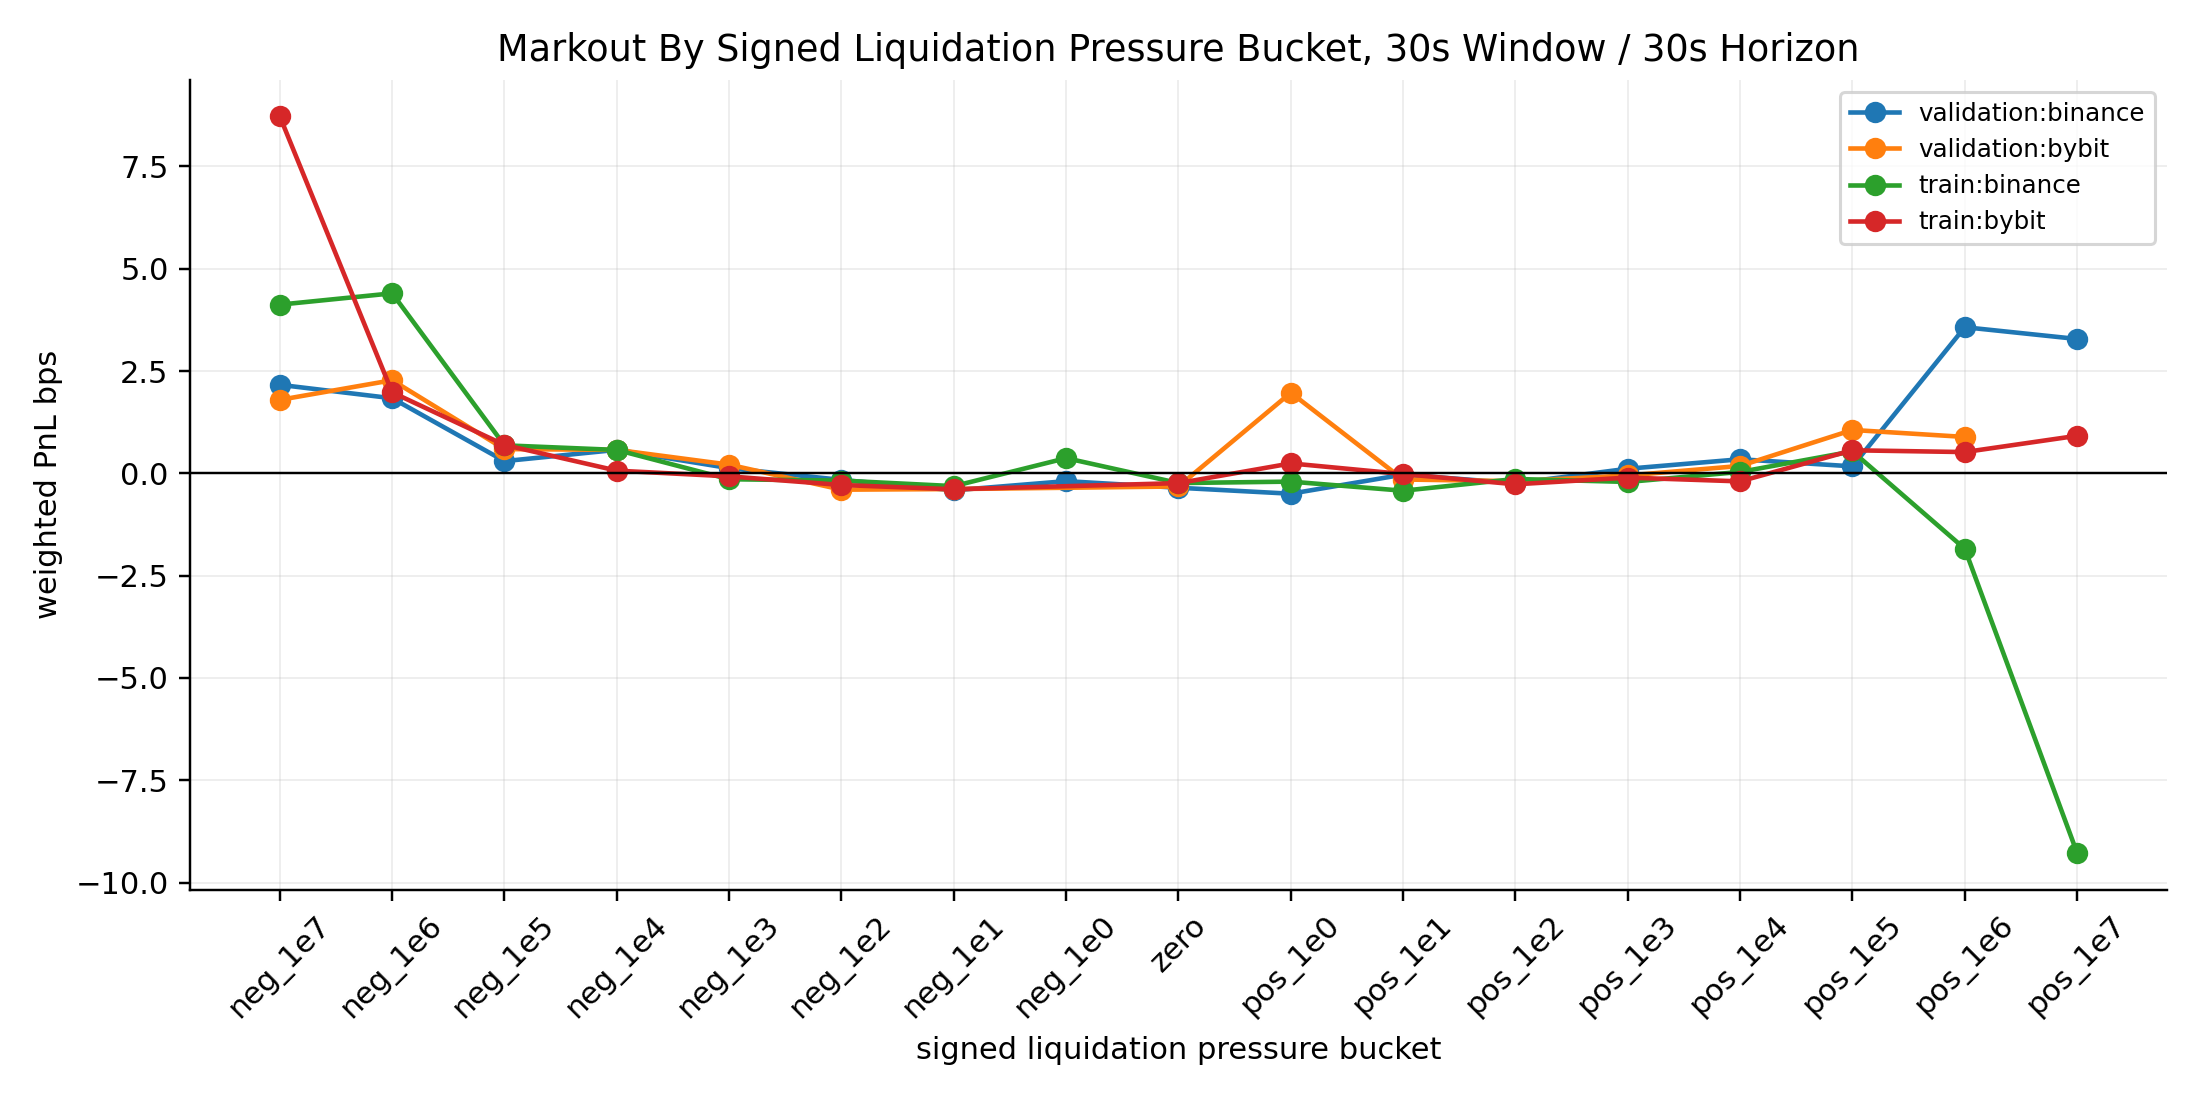

In [28]:
show_figure("nonlinear_flow_response.png")

**Nonlinear response interpretation.** Bucketed pressure diagnostics
are important because liquidation effects are unlikely to be linear.
The zero-pressure bucket acts as a baseline; positive and negative
buckets show whether increasing liquidation pressure changes the
expected maker markout.

In [29]:
signed_response = read_table("signed_flow_response_functions.csv")
display(signed_response.head(28))

,symbol,split,flow_type,horizon_seconds,rows,response_bps,mean_return_bps,abs_signed_flow_musd
0,btcusdt,train,binance_trade_flow,1,211364640,-0.0285138,-0.114477,"759,442"
1,btcusdt,train,binance_trade_flow,5,211363577,-0.0510965,-0.223269,"759,441"
2,btcusdt,train,binance_trade_flow,10,211361120,-0.10907,-0.239025,"759,432"
3,btcusdt,train,binance_trade_flow,30,211347046,-0.158817,-0.225815,"759,382"
4,btcusdt,train,binance_trade_flow,60,211332855,-0.183809,-0.189669,"759,199"
5,btcusdt,train,binance_trade_flow,120,211342395,-0.11455,-0.176654,"759,228"
6,btcusdt,train,binance_trade_flow,300,211361671,0.259875,-0.1755,"759,429"
7,btcusdt,train,binance_liquidation_flow,1,63660,0.873156,-0.00598308,737.614
8,btcusdt,train,binance_liquidation_flow,5,63660,0.749431,0.0181472,737.614
9,btcusdt,train,binance_liquidation_flow,10,63659,0.620862,0.0497788,737.554


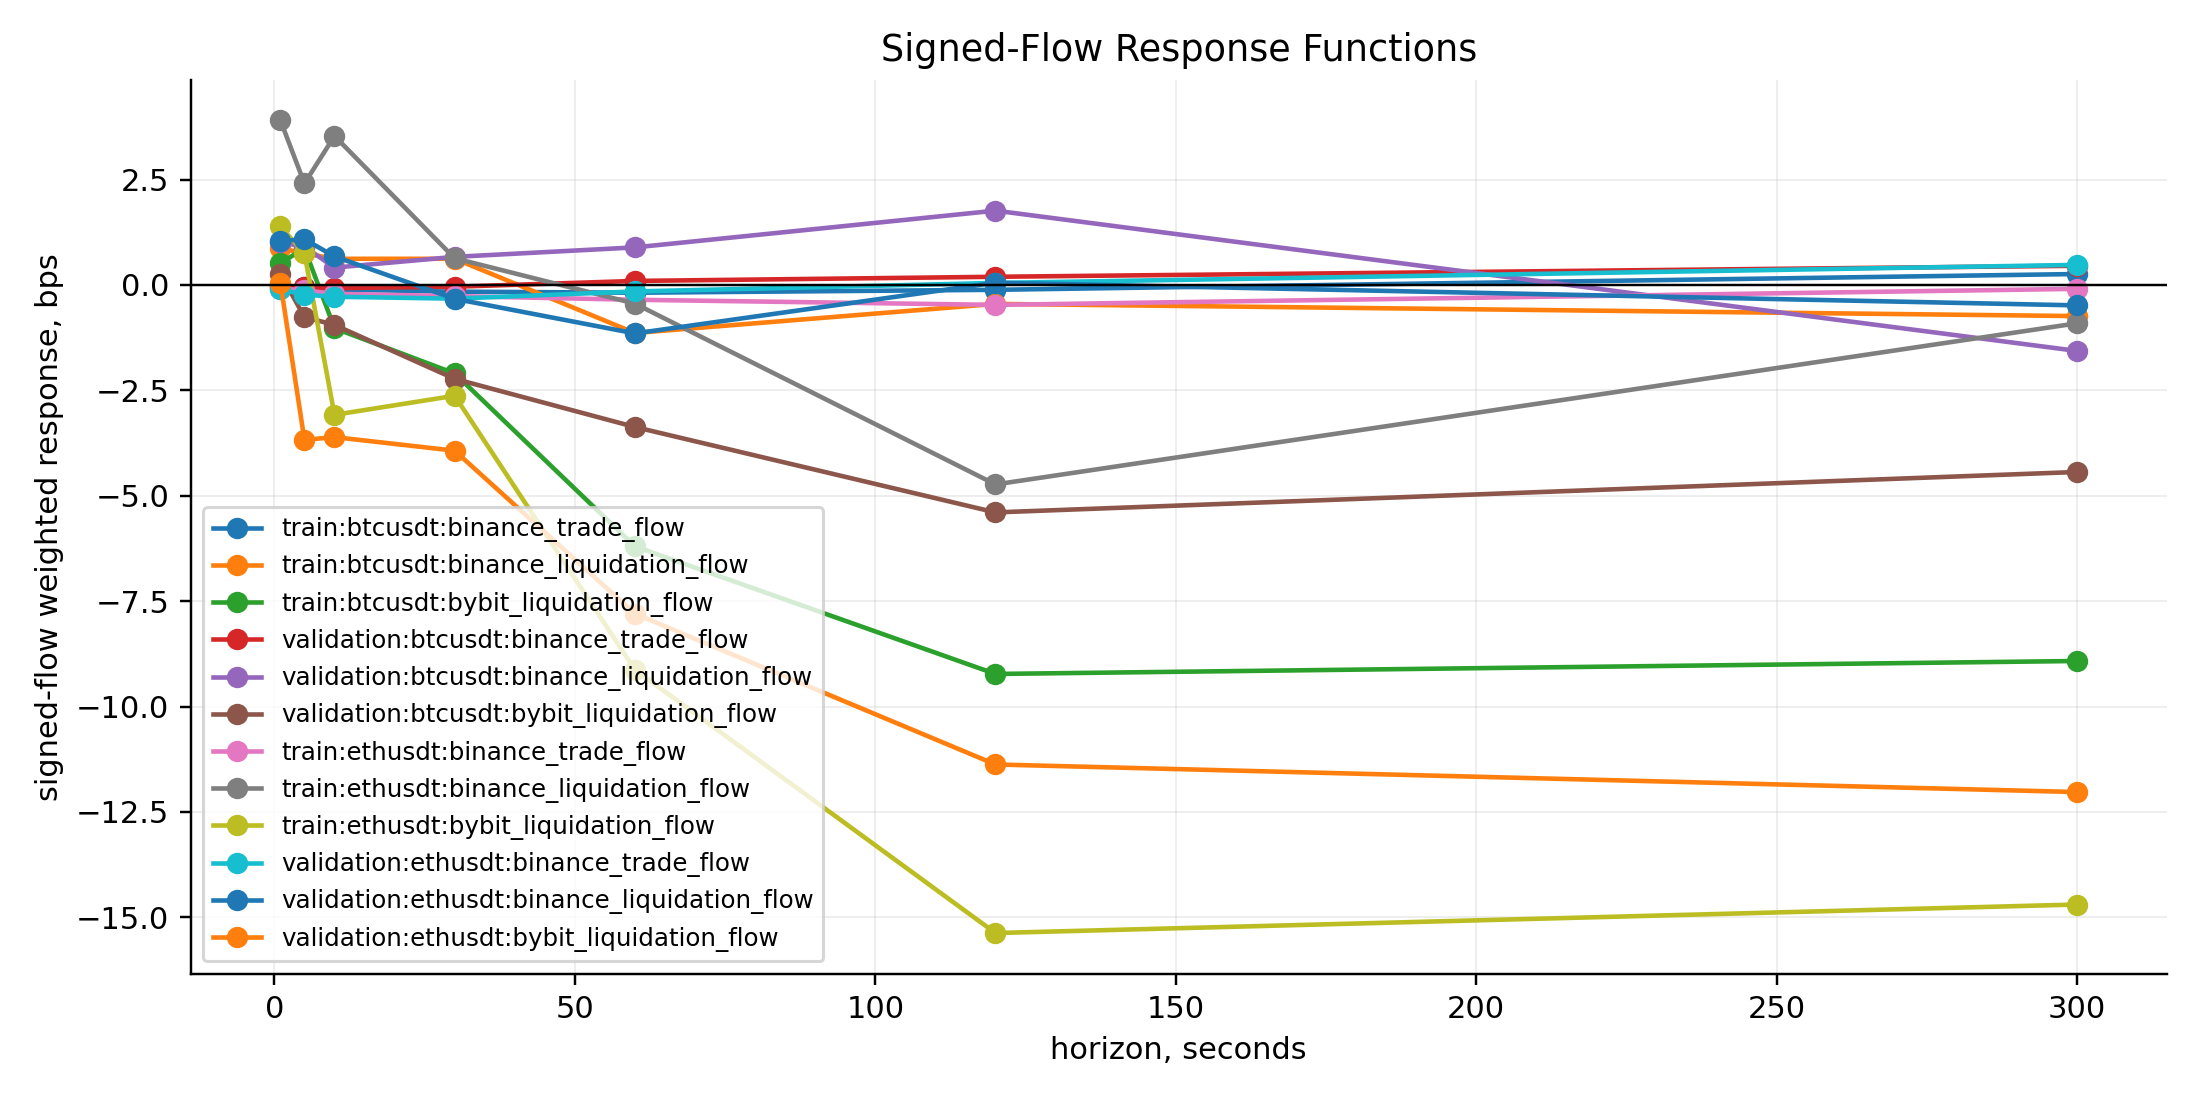

In [30]:
show_figure("signed_flow_response_functions.png")

**Signed response interpretation.** Signed-flow response functions
measure how future mid returns respond to signed trade or
liquidation pressure.  This is the bridge between simple EDA and
market-impact intuition: if signed forced flow has a persistent
response, it can motivate future filtering features.

## 7. True Liquidation Event Study

A true event study aligns the Binance mid-price around liquidation
event time and then averages the return path.  For Bybit the event
time is the delayed availability timestamp, not the raw exchange
timestamp.  This avoids look-ahead in cross-exchange analysis.

In [31]:
event_study = read_table("event_study_summary.csv")
display(event_study.head(20))
display(Markdown(f"`event_study_summary.csv`: {len(event_study):,} rows."))

,split,date,symbol,venue,side,offset_seconds,rows,mean_return_bps,std_return_bps
0,train,2025-12-01,btcusdt,binance,buy,-300,963,-22.0241,26.1233
1,train,2025-12-01,btcusdt,binance,sell,-300,1909,28.0573,25.5448
2,train,2025-12-01,btcusdt,binance,buy,-120,963,-18.9881,16.3908
3,train,2025-12-01,btcusdt,binance,sell,-120,1948,17.966,14.818
4,train,2025-12-01,btcusdt,binance,buy,-60,963,-15.4226,12.4438
5,train,2025-12-01,btcusdt,binance,sell,-60,1952,12.7408,11.0194
6,train,2025-12-01,btcusdt,binance,buy,-30,963,-11.3471,9.23686
7,train,2025-12-01,btcusdt,binance,sell,-30,1952,9.47088,8.99139
8,train,2025-12-01,btcusdt,binance,buy,-10,963,-6.17698,5.9326
9,train,2025-12-01,btcusdt,binance,sell,-10,1956,5.11609,6.08111


`event_study_summary.csv`: 10,800 rows.

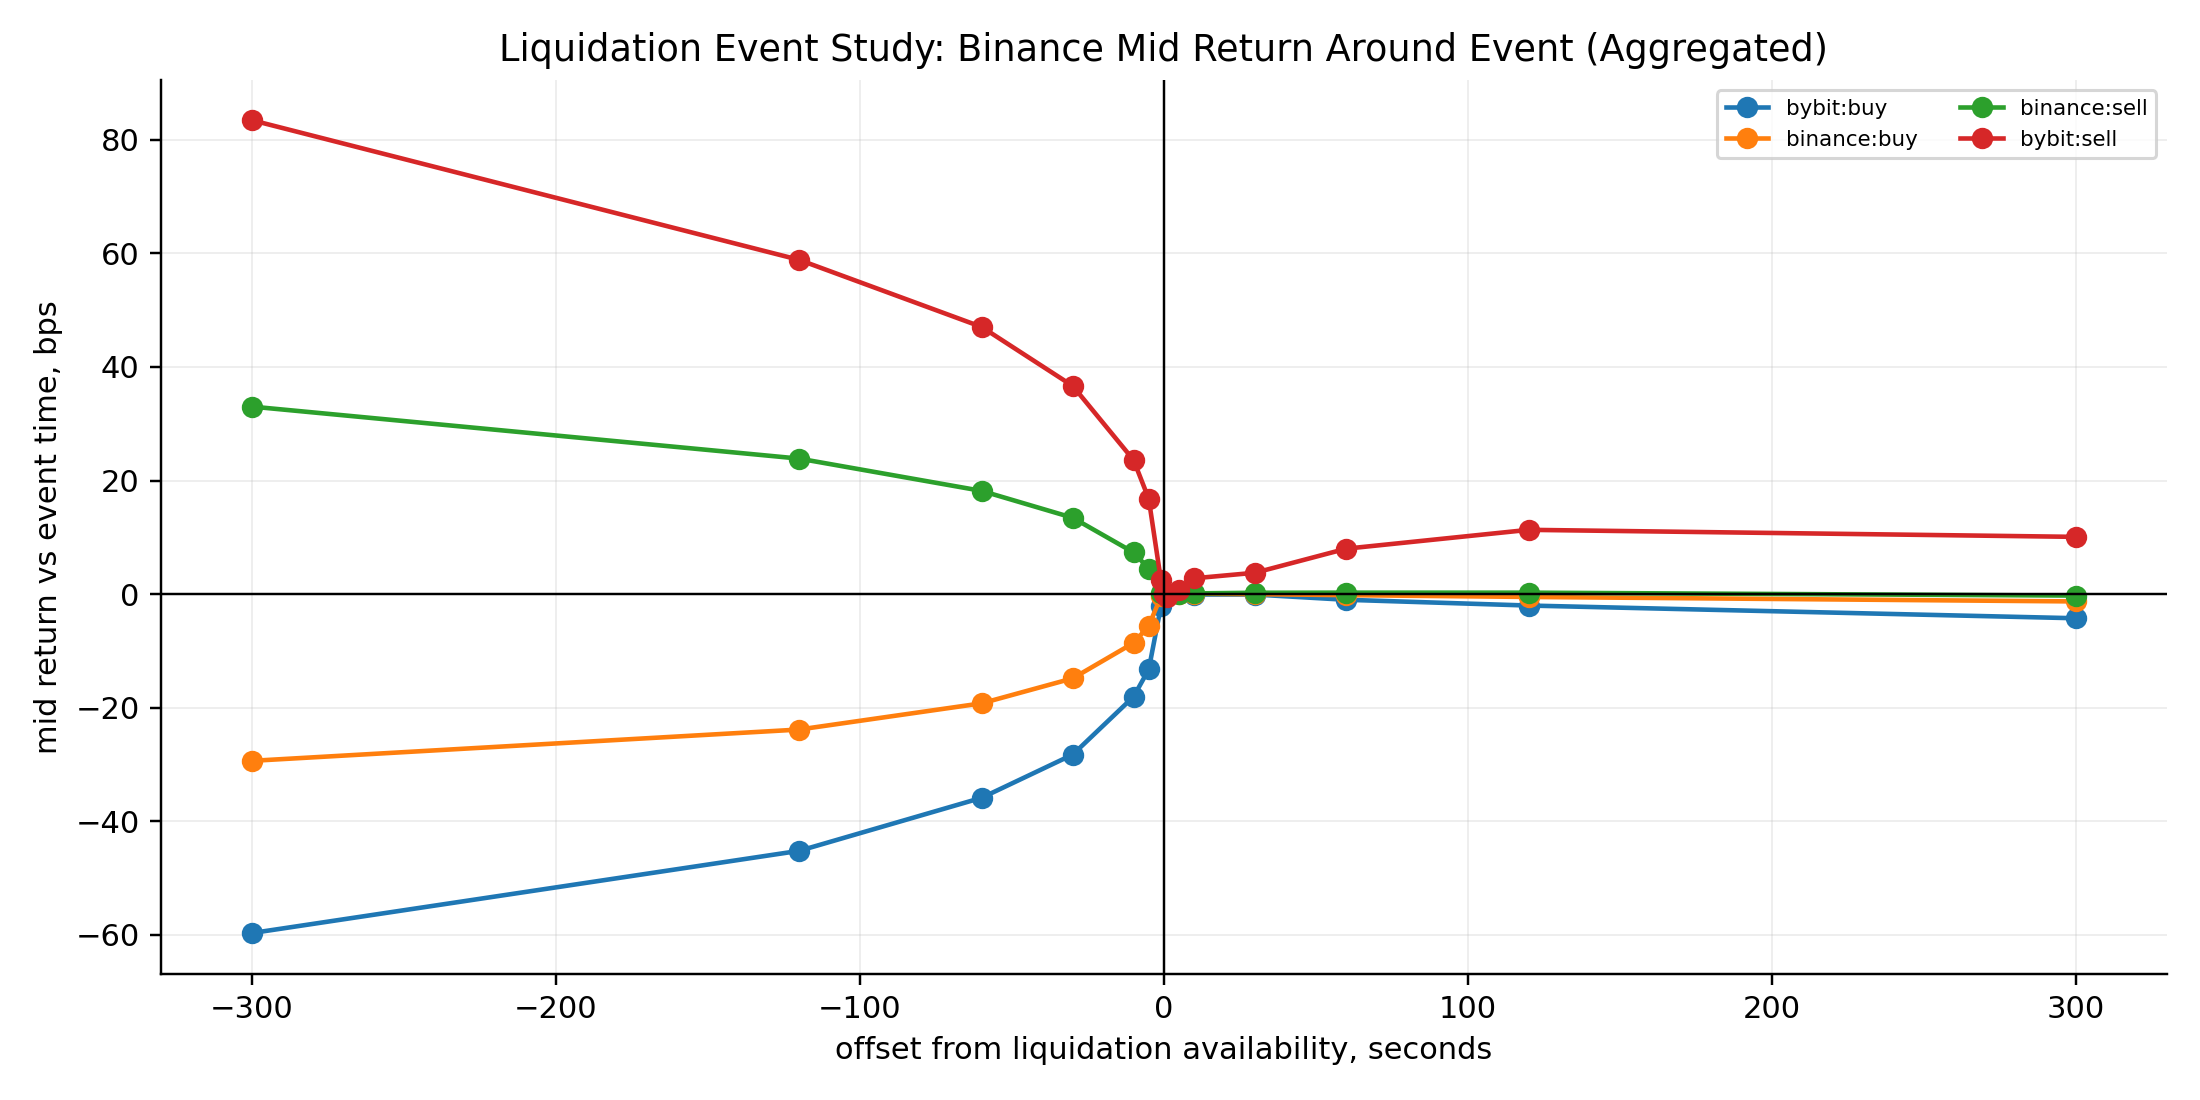

In [32]:
show_figure("liquidation_event_study_mid.png")

**Aggregated event-study interpretation.** This figure aggregates
liquidation event paths by venue and side.  The objective is not to
prove causality but to detect whether the book moves systematically
before or after visible liquidation pressure.

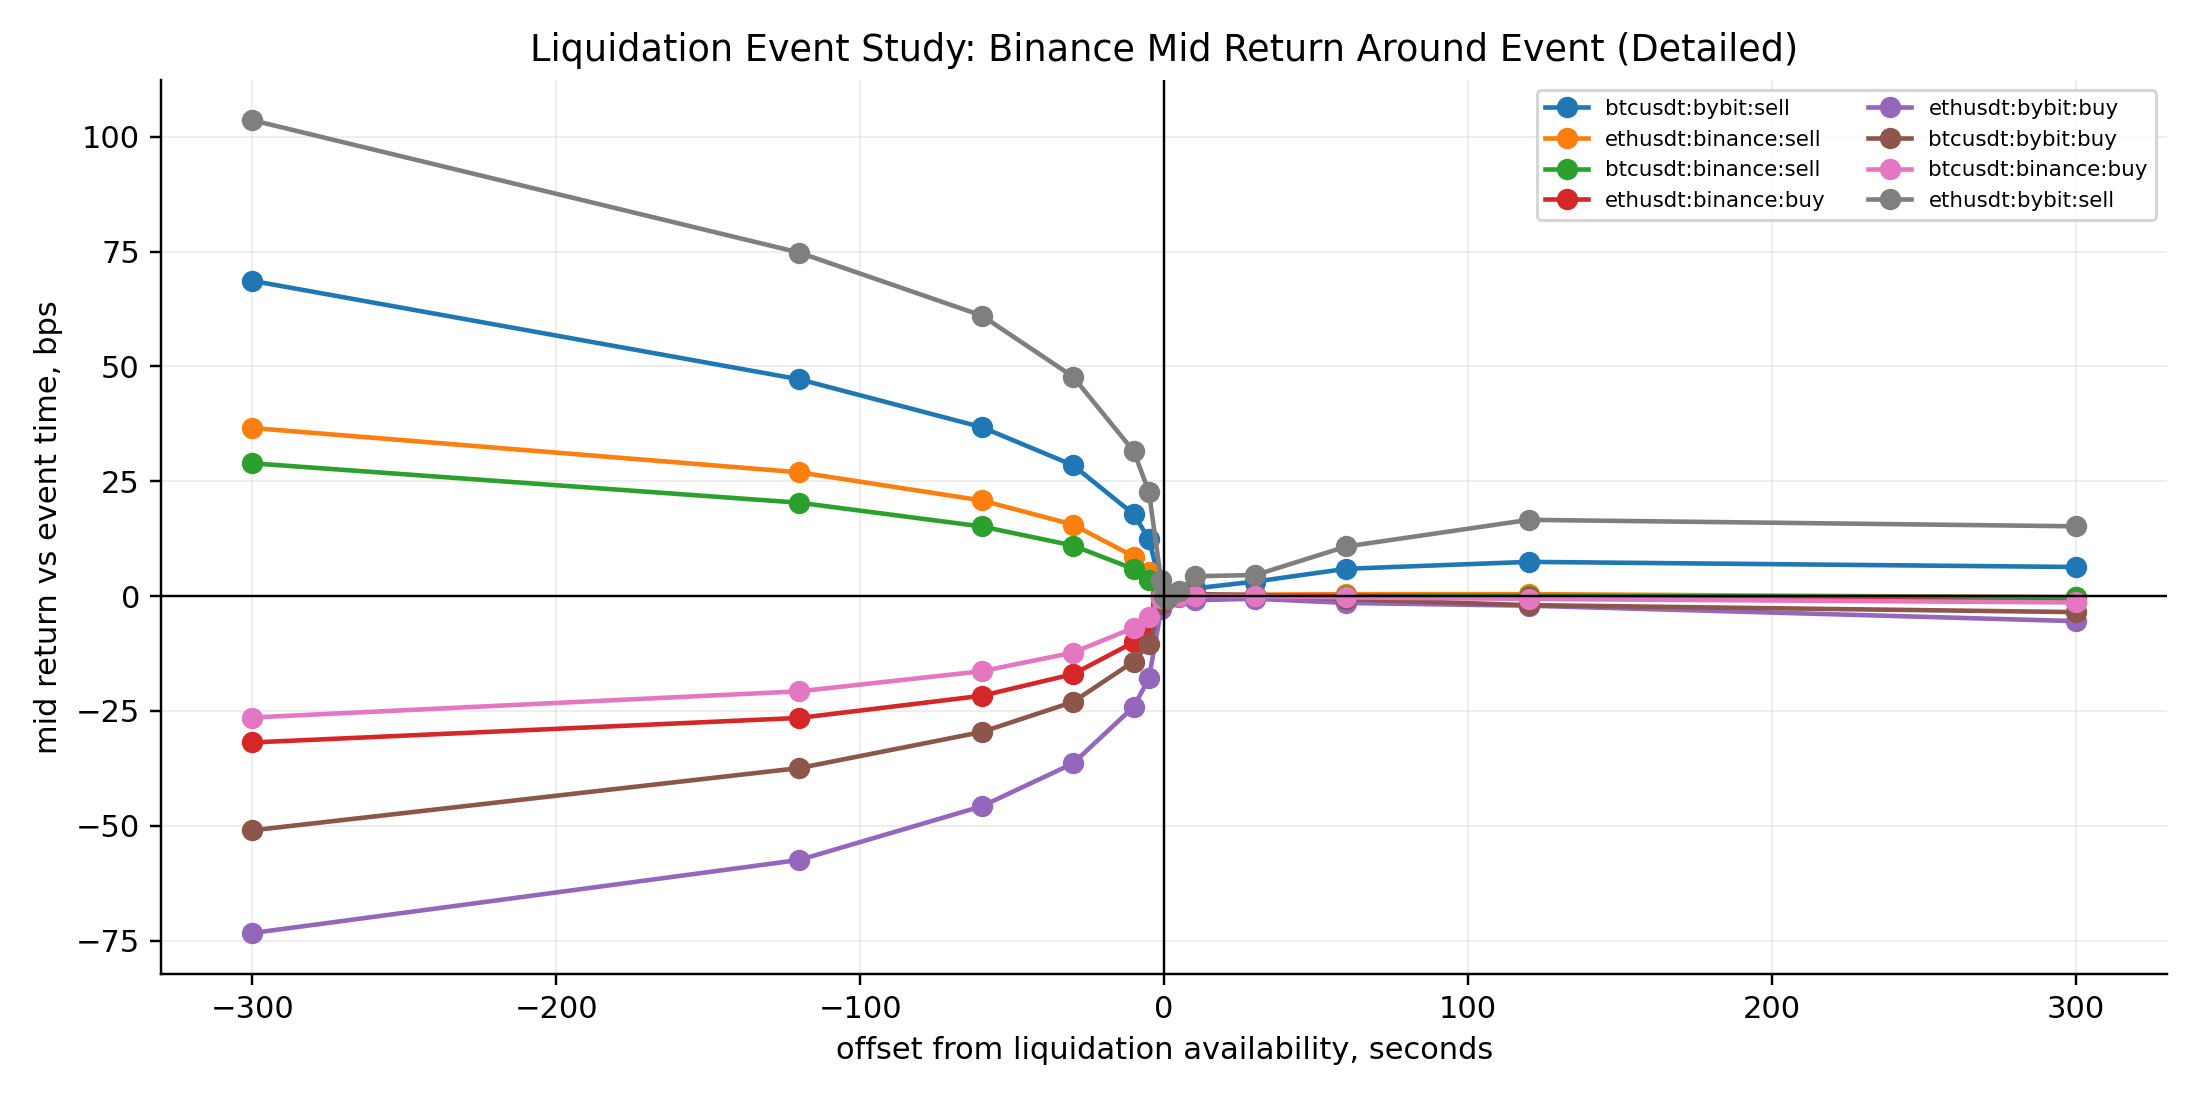

In [33]:
show_figure("liquidation_event_study_by_venue_side_symbol.png")

**Detailed event-study interpretation.** The detailed plot separates
symbol, venue and side.  This is useful for identifying effects that
exist in BTC but not ETH, or on Binance liquidations but not Bybit
liquidations after the 200 ms information delay.

In [34]:
event_wide = (
    event_study[event_study["offset_seconds"].isin([-300, -60, 0, 60, 300])]
    .pivot_table(
        index=["split", "symbol", "venue", "side"],
        columns="offset_seconds",
        values="mean_return_bps",
        aggfunc="mean",
    )
    .reset_index()
)
for col in [-300, -60, 0, 60, 300]:
    if col not in event_wide.columns:
        event_wide[col] = math.nan
event_wide["post_300_minus_event_bps"] = event_wide[300] - event_wide[0]
event_wide["event_minus_pre_300_bps"] = event_wide[0] - event_wide[-300]
display(event_wide.sort_values("post_300_minus_event_bps", ascending=False).head(16))

offset_seconds,split,symbol,venue,side,-300,-60,0,60,300,post_300_minus_event_bps,event_minus_pre_300_bps
7,train,ethusdt,bybit,sell,52.8748,32.6394,0,3.846,7.66924,7.66924,-52.8748
15,validation,ethusdt,bybit,sell,72.4662,40.8009,0,4.38027,5.49126,5.49126,-72.4662
3,train,btcusdt,bybit,sell,35.8138,19.8502,0,2.84243,4.5001,4.5001,-35.8138
11,validation,btcusdt,bybit,sell,53.9304,27.9967,0,1.90087,2.63957,2.63957,-53.9304
9,validation,btcusdt,binance,sell,30.457,16.2954,0,-0.09466,0.711375,0.711375,-30.457
5,train,ethusdt,binance,sell,26.3028,15.4242,0,0.530057,0.607006,0.607006,-26.3028
13,validation,ethusdt,binance,sell,37.5472,21.407,0,0.120149,0.605747,0.605747,-37.5472
1,train,btcusdt,binance,sell,20.0481,10.6306,0,0.285011,0.332193,0.332193,-20.0481
4,train,ethusdt,binance,buy,-23.9776,-15.8414,0,-0.199908,-1.07582,-1.07582,23.9776
0,train,btcusdt,binance,buy,-19.0607,-11.1473,0,-0.339402,-1.09091,-1.09091,19.0607


**Event-study read.** The pre-event leg is as important as the
post-event leg.  If most of the move happens before the liquidation
print is available, the liquidation is mainly a stress marker, not a
tradable leading signal.  If a post-event drift remains after the
Bybit 200 ms delay, that is more promising for a cross-exchange
feature.  The next research step is to separate continuation from
reversal after large liquidation clusters and condition on spread,
OFI and queue imbalance at the time of availability.

## 8. Hypotheses Checked

The exploration supports several concrete hypotheses for a future
signal-design phase:

1. **Queue imbalance is directionally informative.** Conditional
   next-mid-up probability is monotonic in queue imbalance buckets.
2. **OFI carries short-horizon price-formation information.** OFI is
   positively related to next BBO returns in both symbols and both
   splits.
3. **Liquidation context changes maker markout.** Recent signed
   liquidation pressure can shift the distribution of future maker
   markout relative to no-pressure periods.
4. **Effects are conditional, not universal.** Symbol, side, horizon,
   venue and train/validation split all matter.
5. **Timestamp conventions materially matter.** Duplicate trade
   timestamps and cross-source timing mean that backward/as-of
   semantics and Bybit's 200 ms delay must be explicit in any
   future model.

**Practical trading hypothesis.** The most plausible strategy is not
"trade every liquidation".  A more defensible approach is a passive
maker filter: avoid quotes when recent forced flow, OFI and queue
imbalance jointly imply toxic continuation; become more willing to
provide liquidity when forced flow appears exhausted and markout
improves versus the no-pressure baseline.

In [35]:
hypotheses_path = ROOT / "docs" / "research" / "notes" / "liquidation_signal_hypotheses.md"
if hypotheses_path.exists():
    text = hypotheses_path.read_text(encoding="utf-8")
    display(Markdown(text[:5000] + ("\n\n..." if len(text) > 5000 else "")))
else:
    display(Markdown("Hypotheses note was not found."))

# Liquidation Signal Hypotheses

Generated from the liquidation EDA pipeline.

## Empirical Pointers From Current EDA

- Source coverage spans 2025-12-01 through 2026-02-28 for both BTCUSDT and ETHUSDT.
- Binance trades have many duplicate timestamps, so same-timestamp ordering must not be inferred.
- Full-data BBO quality, markout, liquidation context, response, and event-study tables are computed with daily chunks.
- Deterministic samples are retained only for visual distribution plots.

- Strongest full-data liquidation-context bucket by weighted maker PnL: ethusdt buy 300s upward_pressure / same_direction_toxic_risk = 11.3889 bps.
- Weakest full-data liquidation-context bucket by weighted maker PnL: ethusdt sell 300s upward_pressure / opposite_direction = -10.2294 bps.

## Strong Candidates To Test Later

- Same-direction liquidation pressure may identify toxic maker trades, but the direction is not uniform across symbol/side/horizon and must be validated split-by-split.
- Bybit liquidation clusters may lead Binance adverse selection after the required 200ms delay.
- OFI and queue imbalance may help distinguish toxic flow from ordinary trade flow.
- Extreme signed liquidation pressure may be nonlinear: saturation or reversal should be modeled.
- The future filter should use only known-at-time liquidation/BBO/trade features and should evaluate kept turnover against the 500k USD/day constraint.

## Risks

- Full EDA stores compact aggregates, not every enriched trade row.
- Liquidation response is descriptive, not causal proof.
- Same-timestamp ordering remains ambiguous in public data.
- A full production signal still needs a separate feature-generation path that returns one filter value per trade.

## Evidence Pointer

See `reports/liquidation_eda/tables/markout_by_liquidation_context.csv`.


## 9. Limitations and Next Steps

**Limitations.**

- Same-timestamp event ordering is not recoverable from these files
  because no sequence id is provided.
- Distribution plots use deterministic visual samples; conclusions
  are based on full-data aggregate tables.
- The EDA is descriptive.  It does not yet define a final binary
  filter, train a model, or estimate live execution PnL.
- Markouts are labels/diagnostics, not executable profits by
  themselves.

**Next steps.**

- Build candidate features from queue imbalance, OFI, recent
  liquidation pressure, cross-venue pressure and volatility regime.
- Use chronological train/validation only; keep any final test or
  hidden set untouched.
- Evaluate a simple interpretable binary filter before considering
  more complex ML.
- Validate stability by symbol, side, day and market regime.

In [36]:
final_checks = pd.DataFrame(
    [
        ("full-data Binance trade coverage", bool(coverage_check.loc[coverage_check["family"] == "Binance trades", "match"].iloc[0])),
        ("full-data Binance BBO coverage", bool(coverage_check.loc[coverage_check["family"] == "Binance BBO", "match"].iloc[0])),
        ("required report exists", (REPORT_DIR / "liquidation_eda_report.md").exists()),
        ("figures directory exists", FIG_DIR.exists()),
        ("tables directory exists", TABLE_DIR.exists()),
        ("Bybit delay documented", True),
        ("no raw parquet embedded in notebook", True),
    ],
    columns=["check", "passed"],
)
display(final_checks)
assert final_checks["passed"].all()

,check,passed
0,full-data Binance trade coverage,True
1,full-data Binance BBO coverage,True
2,required report exists,True
3,figures directory exists,True
4,tables directory exists,True
5,Bybit delay documented,True
6,no raw parquet embedded in notebook,True


## Appendix: Optional Full Pipeline Command

The cell below is intentionally non-running by default.  Turn
`RUN_FULL_PIPELINE` to `True` only when you want to regenerate all
full-data artifacts from raw parquet files.  The latest full run took
roughly 98 minutes on the local machine.

In [37]:
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    import subprocess
    cmd = [
        str(ROOT / ".venv" / "bin" / "python"),
        "-m",
        "cmf_backtester.main",
        "run-liquidation-eda",
        "--config",
        "configs/liquidation_eda.yaml",
        "--profile",
        "full",
    ]
    subprocess.run(cmd, cwd=ROOT, check=True, env={**__import__("os").environ, "PYTHONPATH": "src"})
else:
    display(Markdown("Full pipeline execution skipped. Existing full-data artifacts were loaded above."))

Full pipeline execution skipped. Existing full-data artifacts were loaded above.